https://calcofi.org/data/oceanographic-data/bottle-database/
Regression - Predicting a continuous value
Problem:
CalCOFI data: Over 60 years of oceanographic data: Is there a relationship between water salinity & water temperature? Can you predict the water temperature based on salinity?

In [2]:
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt #plotting
import numpy as np #linear algebra
import os #accessing directory structure
import pandas as pd #data processing
import math
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict
import operator
from scipy import stats #Boxcox Transformation
import plotly.express as px
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay,classification_report,mean_squared_error,mean_absolute_error, r2_score
import shap
from lime.lime_tabular import LimeTabularExplainer

In [3]:
print (os.listdir('/Users/steffidorothy/Downloads/KDD/project 3'))

['.DS_Store', 'project3.ipynb', 'bottle.csv', '.ipynb_checkpoints', 'cast.csv']


Functions For Plotting Data

In [5]:
#Distribution Graphs Of Column Data (histogram/bar)
def plotpercolumn(df, ngraphshown, ngraphperrow):
    nunique = df.nunique()
    df = df[[col for col in df if nunique[col] > 1 and nunique[col] < 50]] #pick columns that have between 1 and 50 unique values
    nrow, ncol = df.shape
    columnnames = list(df)
    ngraphrow = math.ceil(min(ncol,ngraphshown) / ngraphperrow)
    plt.figure(num = None, figsize = (6 * ngraphperrow, 8 * ngraphrow), dpi = 80, facecolor = 'w', edgecolor = 'k')
    for i in range(min(ncol, ngraphshown)):
        plt.subplot(ngraphrow, ngraphperrow, i + 1)
        columndf = df.iloc[:, i]
        if (not np.issubdtype(type(columndf.iloc[0]), np.number)):
            valuecounts = columndf.value_counts()
            valuecounts.plot.bar()
        else:
            columndf.hist()
        plt.ylabel('counts')
        plt.xticks(rotation = 90)
        plt.title(f'{columnnames[i]} (column {i})')
    plt.tight_layout(pad = 1.0, w_pad = 1.0, h_pad = 1.0)
    plt.show()

In [6]:
# Correlation matrix
def plotcorr(df, graphwidth):
    df = df.dropna(axis='columns') # drop columns with NaN
    # Convert all columns to numeric, forcing errors to NaN
    df = df.apply(pd.to_numeric, errors='coerce')
    df = df[[col for col in df if df[col].nunique() > 1]] # keep columns where there are more than 1 unique values
    if df.shape[1] < 2:
        print(f'No correlation plots shown: ({df.shape[1]}) is less than 2')
        return
    corr = df.corr()
    plt.figure(num=None, figsize=(graphwidth, graphwidth), dpi=80, facecolor='w', edgecolor='k')
    corrmat = plt.matshow(corr, fignum = 1)
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.columns)), corr.columns)
    plt.gca().xaxis.tick_bottom()
    plt.colorbar(corrmat)
    plt.title(f'Correlation Matrix', fontsize=15)
    plt.show()

In [7]:
#Scatter and density plots
def plotscatter(df, plotsize, textsize):
    df=df.select_dtypes(include=[np.number])#keep only numerical columns
    df=df.dropna(axis='columns')
    df=df[[ col for col in df if df[col].nunique()>1]] #keep columns that have more than 1 unique value
    columnnames=list(df)
    if len (columnnames)>10:#reduce the number of columns for matrix inversion of kernel density plots
        columnnames=columnnames[:10]
    df=df[columnnames]
    ax=pd.plotting.scatter_matrix(df, alpha=0.75, figsize=[plotsize, plotsize], diagonal='kde')
    corrs=df.corr().values
    for i, j in zip(*plt.np.triu_indices_from(ax, k=1)):
        ax[i,j].annotate('Corr.coef=%.3f'%corrs[i,j], (0.8, 0.2), xycoords='axes fraction', ha='center', va='center', size=textsize)
        plt.suptitle("Scatter And Density Plot")
        plt.show()

bottle.csv

In [9]:
nrowsread=None
df1=pd.read_csv('/Users/steffidorothy/Downloads/KDD/project 3/bottle.csv', delimiter=',', nrows=nrowsread)
df1.dataframeName='bottle.csv'
nrow, ncol=df1.shape
print(f'There are {nrow} rows and {ncol}columns')

/var/folders/01/p9wdd6714s9db6szcr48p6pw0000gn/T/ipykernel_12284/3860665716.py:2: DtypeWarning: Columns (47,73) have mixed types. Specify dtype option on import or set low_memory=False.
  df1=pd.read_csv('/Users/steffidorothy/Downloads/KDD/project 3/bottle.csv', delimiter=',', nrows=nrowsread)


There are 864863 rows and 74columns


In [10]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 864863 entries, 0 to 864862
Data columns (total 74 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Cst_Cnt              864863 non-null  int64  
 1   Btl_Cnt              864863 non-null  int64  
 2   Sta_ID               864863 non-null  object 
 3   Depth_ID             864863 non-null  object 
 4   Depthm               864863 non-null  int64  
 5   T_degC               853900 non-null  float64
 6   Salnty               817509 non-null  float64
 7   O2ml_L               696201 non-null  float64
 8   STheta               812174 non-null  float64
 9   O2Sat                661274 non-null  float64
 10  Oxy_µmol/Kg          661268 non-null  float64
 11  BtlNum               118667 non-null  float64
 12  RecInd               864863 non-null  int64  
 13  T_prec               853900 non-null  float64
 14  T_qual               23127 non-null   float64
 15  S_prec           

How the data looks like:

In [12]:
df1.head(5)

,Cst_Cnt,Btl_Cnt,Sta_ID,Depth_ID,Depthm,T_degC,Salnty,O2ml_L,STheta,O2Sat,...,R_PHAEO,R_PRES,R_SAMP,DIC1,DIC2,TA1,TA2,pH2,pH1,DIC Quality Comment
0,1,1,054.0 056.0,19-4903CR-HY-060-0930-05400560-0000A-3,0,10.50,33.440,NaN,25.649,NaN,...,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2,054.0 056.0,19-4903CR-HY-060-0930-05400560-0008A-3,8,10.46,33.440,NaN,25.656,NaN,...,NaN,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,3,054.0 056.0,19-4903CR-HY-060-0930-05400560-0010A-7,10,10.46,33.437,NaN,25.654,NaN,...,NaN,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,4,054.0 056.0,19-4903CR-HY-060-0930-05400560-0019A-3,19,10.45,33.420,NaN,25.643,NaN,...,NaN,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,5,054.0 056.0,19-4903CR-HY-060-0930-05400560-0020A-7,20,10.45,33.421,NaN,25.643,NaN,...,NaN,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [764]:
columns = [col for col in df1.columns if (df1[col].isnull().sum() / df1.shape[0]) <= 0.07]
print(columns)
print(f"we will delete {df1.shape[1] - len(columns)} ")

['Cst_Cnt', 'Btl_Cnt', 'Sta_ID', 'Depth_ID', 'Depthm', 'T_degC', 'Salnty', 'STheta', 'RecInd', 'T_prec', 'S_prec', 'NH3q', 'C14A1q', 'C14A2q', 'DarkAq', 'MeanAq', 'R_Depth', 'R_TEMP', 'R_POTEMP', 'R_SALINITY', 'R_SIGMA', 'R_SVA', 'R_DYNHT', 'R_PRES']
we will delete 50 


In [544]:
df = df1[columns]

In [546]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 864863 entries, 0 to 864862
Data columns (total 24 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Cst_Cnt     864863 non-null  int64  
 1   Btl_Cnt     864863 non-null  int64  
 2   Sta_ID      864863 non-null  object 
 3   Depth_ID    864863 non-null  object 
 4   Depthm      864863 non-null  int64  
 5   T_degC      853900 non-null  float64
 6   Salnty      817509 non-null  float64
 7   STheta      812174 non-null  float64
 8   RecInd      864863 non-null  int64  
 9   T_prec      853900 non-null  float64
 10  S_prec      817509 non-null  float64
 11  NH3q        808299 non-null  float64
 12  C14A1q      848605 non-null  float64
 13  C14A2q      848623 non-null  float64
 14  DarkAq      840440 non-null  float64
 15  MeanAq      840439 non-null  float64
 16  R_Depth     864863 non-null  float64
 17  R_TEMP      853900 non-null  float64
 18  R_POTEMP    818816 non-null  float64
 19  R_

In [548]:
df.select_dtypes("object").head()

,Sta_ID,Depth_ID
0,054.0 056.0,19-4903CR-HY-060-0930-05400560-0000A-3
1,054.0 056.0,19-4903CR-HY-060-0930-05400560-0008A-3
2,054.0 056.0,19-4903CR-HY-060-0930-05400560-0010A-7
3,054.0 056.0,19-4903CR-HY-060-0930-05400560-0019A-3
4,054.0 056.0,19-4903CR-HY-060-0930-05400560-0020A-7


In [550]:
df.drop(["Sta_ID", "Depth_ID"], axis=1, inplace=True)

/var/folders/01/p9wdd6714s9db6szcr48p6pw0000gn/T/ipykernel_84809/1064981062.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(["Sta_ID", "Depth_ID"], axis=1, inplace=True)


In [552]:
df.head()

,Cst_Cnt,Btl_Cnt,Depthm,T_degC,Salnty,STheta,RecInd,T_prec,S_prec,NH3q,...,DarkAq,MeanAq,R_Depth,R_TEMP,R_POTEMP,R_SALINITY,R_SIGMA,R_SVA,R_DYNHT,R_PRES
0,1,1,0,10.50,33.440,25.649,3,1.0,2.0,9.0,...,9.0,9.0,0.0,10.50,10.50,33.440,25.64,233.0,0.00,0
1,1,2,8,10.46,33.440,25.656,3,2.0,2.0,9.0,...,9.0,9.0,8.0,10.46,10.46,33.440,25.65,232.5,0.01,8
2,1,3,10,10.46,33.437,25.654,7,2.0,3.0,9.0,...,9.0,9.0,10.0,10.46,10.46,33.437,25.65,232.8,0.02,10
3,1,4,19,10.45,33.420,25.643,3,2.0,2.0,9.0,...,9.0,9.0,19.0,10.45,10.45,33.420,25.64,234.1,0.04,19
4,1,5,20,10.45,33.421,25.643,7,2.0,3.0,9.0,...,9.0,9.0,20.0,10.45,10.45,33.421,25.64,234.0,0.04,20


In [554]:
df.shape

(864863, 22)

In [131]:
df.dropna(axis=0, inplace=True)

/var/folders/01/p9wdd6714s9db6szcr48p6pw0000gn/T/ipykernel_84809/2089189907.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(axis=0, inplace=True)


In [132]:
df.isnull().sum()

Cst_Cnt       0
Btl_Cnt       0
Depthm        0
T_degC        0
Salnty        0
STheta        0
RecInd        0
T_prec        0
S_prec        0
NH3q          0
C14A1q        0
C14A2q        0
DarkAq        0
MeanAq        0
R_Depth       0
R_TEMP        0
R_POTEMP      0
R_SALINITY    0
R_SIGMA       0
R_SVA         0
R_DYNHT       0
R_PRES        0
dtype: int64

In [133]:
df.shape

(733418, 22)

In [134]:
# selecting Integer datatypes columns
df1_int = df.select_dtypes(include=["int64"])
# selecting float datatypes columns
df1_float = df.select_dtypes(include=["float64"])

df1_int.head()

,Cst_Cnt,Btl_Cnt,Depthm,RecInd,R_PRES
0,1,1,0,3,0
1,1,2,8,3,8
2,1,3,10,7,10
3,1,4,19,3,19
4,1,5,20,7,20


In [135]:
# the unique values of the RecInd
df["RecInd"].value_counts(ascending=False)

RecInd
3    376861
7    275121
5     80506
6       928
4         2
Name: count, dtype: int64

In [136]:
df["RecInd"].head()

0    3
1    3
2    7
3    3
4    7
Name: RecInd, dtype: int64

In [694]:
encoder = OneHotEncoder(sparse_output=False)

# Apply one_hot encodig to the RecInd column
RecInd_encoded = encoder.fit_transform(df["RecInd"].to_numpy().reshape((-1, 1)))

# create a dataframe to concatnate RecInd_encoded data with the original df
RecInd_encoded_df1 = pd.DataFrame(
    RecInd_encoded, columns=encoder.get_feature_names_out(["RecInd"])
)

RecInd_encoded_df1.shape

(864863, 5)

In [696]:
# Ensure the indices of both DataFrames are aligned
df1 = df.reset_index(drop=True)
RecInd_encoded_df1 = RecInd_encoded_df1.reset_index(drop=True)

# Concatenate the one-hot encoded dataframe with the original dataframe
df1 = pd.concat([df, RecInd_encoded_df1], axis=1)

# drop RecInd original column
df1.drop(columns=["RecInd"], axis=1, inplace=True)
df1.head()

,Cst_Cnt,Btl_Cnt,Depthm,T_degC,Salnty,STheta,T_prec,S_prec,NH3q,C14A1q,...,R_SALINITY,R_SIGMA,R_SVA,R_DYNHT,R_PRES,RecInd_3,RecInd_4,RecInd_5,RecInd_6,RecInd_7
0,1,1,0,10.50,33.440,25.649,1.0,2.0,9.0,9.0,...,33.440,25.64,233.0,0.00,0,1.0,0.0,0.0,0.0,0.0
1,1,2,8,10.46,33.440,25.656,2.0,2.0,9.0,9.0,...,33.440,25.65,232.5,0.01,8,1.0,0.0,0.0,0.0,0.0
2,1,3,10,10.46,33.437,25.654,2.0,3.0,9.0,9.0,...,33.437,25.65,232.8,0.02,10,0.0,0.0,0.0,0.0,1.0
3,1,4,19,10.45,33.420,25.643,2.0,2.0,9.0,9.0,...,33.420,25.64,234.1,0.04,19,1.0,0.0,0.0,0.0,0.0
4,1,5,20,10.45,33.421,25.643,2.0,3.0,9.0,9.0,...,33.421,25.64,234.0,0.04,20,0.0,0.0,0.0,0.0,1.0


In [139]:
log_int_cols = [col for col in df1_int.columns if col != "RecInd"]
for col in log_int_cols:
    df[col] = np.log1p(df[col])

In [140]:
df1_float.describe()

,T_degC,Salnty,STheta,T_prec,S_prec,NH3q,C14A1q,C14A2q,DarkAq,MeanAq,R_Depth,R_TEMP,R_POTEMP,R_SALINITY,R_SIGMA,R_SVA,R_DYNHT
count,733418.000000,733418.000000,733418.000000,733418.000000,733418.000000,733418.000000,733418.000000,733418.000000,733418.000000,733418.000000,733418.000000,733418.000000,733418.000000,733418.000000,733418.000000,733418.000000,733418.000000
mean,10.764656,33.861743,25.848316,2.018854,2.694038,8.944438,8.999992,8.999992,8.999992,8.999992,228.063188,10.764664,10.742996,33.861723,25.843458,217.910797,0.447131
std,4.242786,0.460998,1.180908,0.154670,0.460814,0.524139,0.002860,0.002860,0.002860,0.002860,309.103071,4.242788,4.259768,0.461000,1.133141,93.118892,0.388606
min,1.440000,28.431000,20.934000,1.000000,2.000000,4.000000,8.000000,8.000000,8.000000,8.000000,0.000000,1.440000,0.000000,28.431000,20.934000,0.400000,0.000000
25%,7.670000,33.510000,25.004000,2.000000,2.000000,9.000000,9.000000,9.000000,9.000000,9.000000,50.000000,7.670000,7.640000,33.510000,25.000000,142.200000,0.150000
50%,9.980000,33.900000,26.043000,2.000000,3.000000,9.000000,9.000000,9.000000,9.000000,9.000000,125.000000,9.980000,9.970000,33.900000,26.040000,198.300000,0.360000
75%,13.780000,34.210000,26.661000,2.000000,3.000000,9.000000,9.000000,9.000000,9.000000,9.000000,300.000000,13.780000,13.770000,34.210000,26.660000,295.700000,0.650000
max,31.140000,37.034000,250.784000,3.000000,3.000000,9.000000,9.000000,9.000000,9.000000,9.000000,5351.000000,31.140000,31.140000,37.034000,250.784000,683.400000,3.880000


EDA

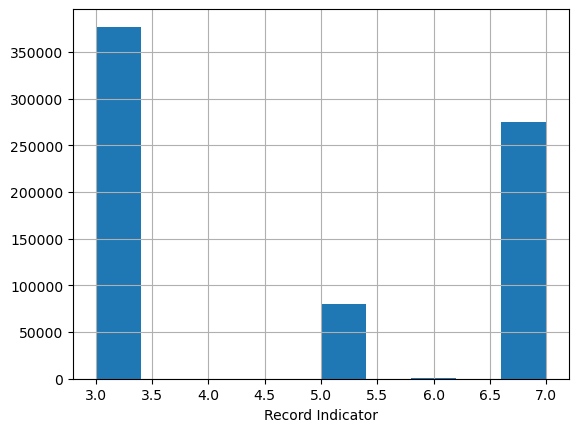

In [142]:
# histogram of RecInd
df["RecInd"].hist(grid=True)
plt.xlabel('Record Indicator')
plt.show()

In [143]:
#Descriptive Statistics
df1_int.describe()

,Cst_Cnt,Btl_Cnt,Depthm,RecInd,R_PRES
count,733418.000000,733418.000000,733418.000000,733418.000000,733418.000000
mean,16421.194724,414217.185100,228.062580,4.723822,229.580553
std,9482.694845,230069.296792,309.103372,1.865705,312.359267
min,1.000000,1.000000,0.000000,3.000000,0.000000
25%,8492.000000,222666.250000,50.000000,3.000000,50.000000
50%,15633.000000,412554.500000,125.000000,3.000000,126.000000
75%,24876.000000,608509.750000,300.000000,7.000000,302.000000
max,34404.000000,864861.000000,5351.000000,7.000000,5458.000000


Distribution Graphs Of Sampled Columns

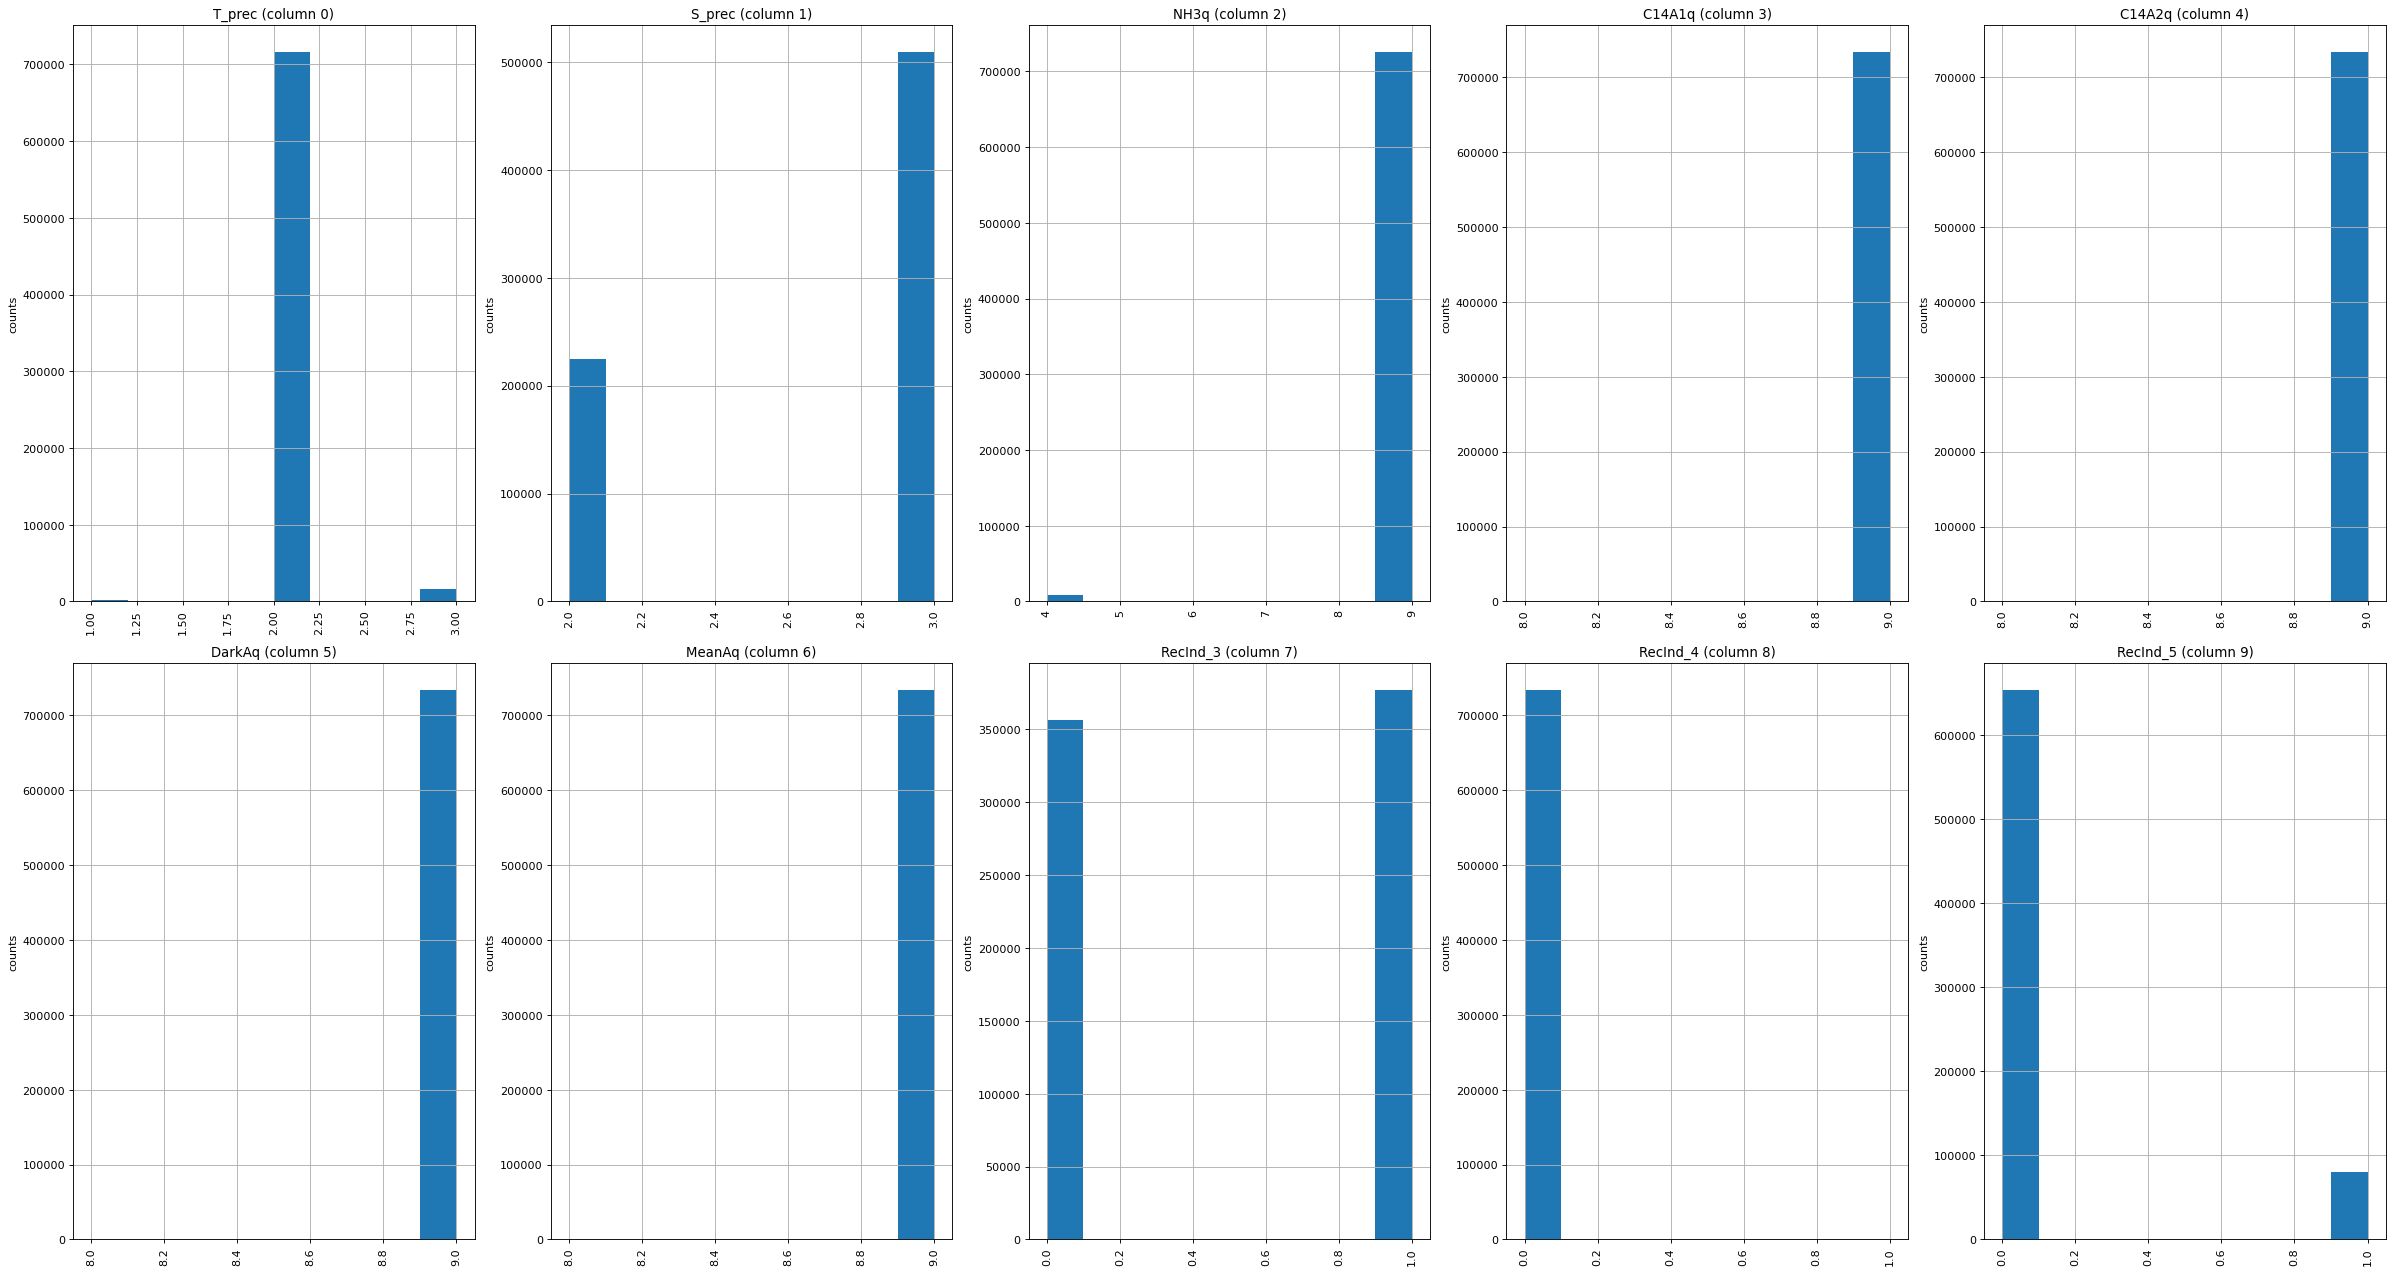

In [145]:
plotpercolumn(df1, 10, 5)

Correlation Matrix

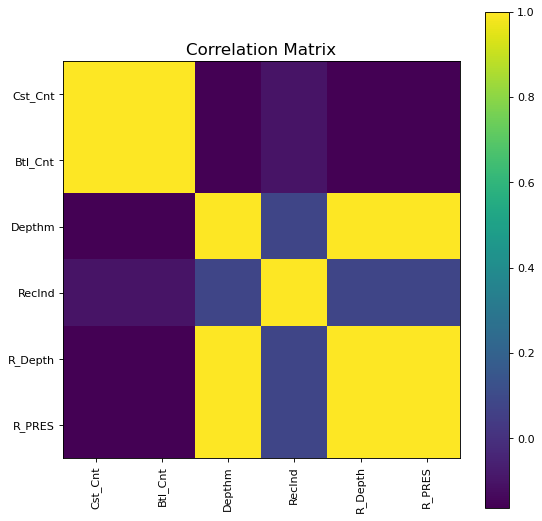

In [210]:
plotcorr(df1, 8)

Scatter And Density Plots

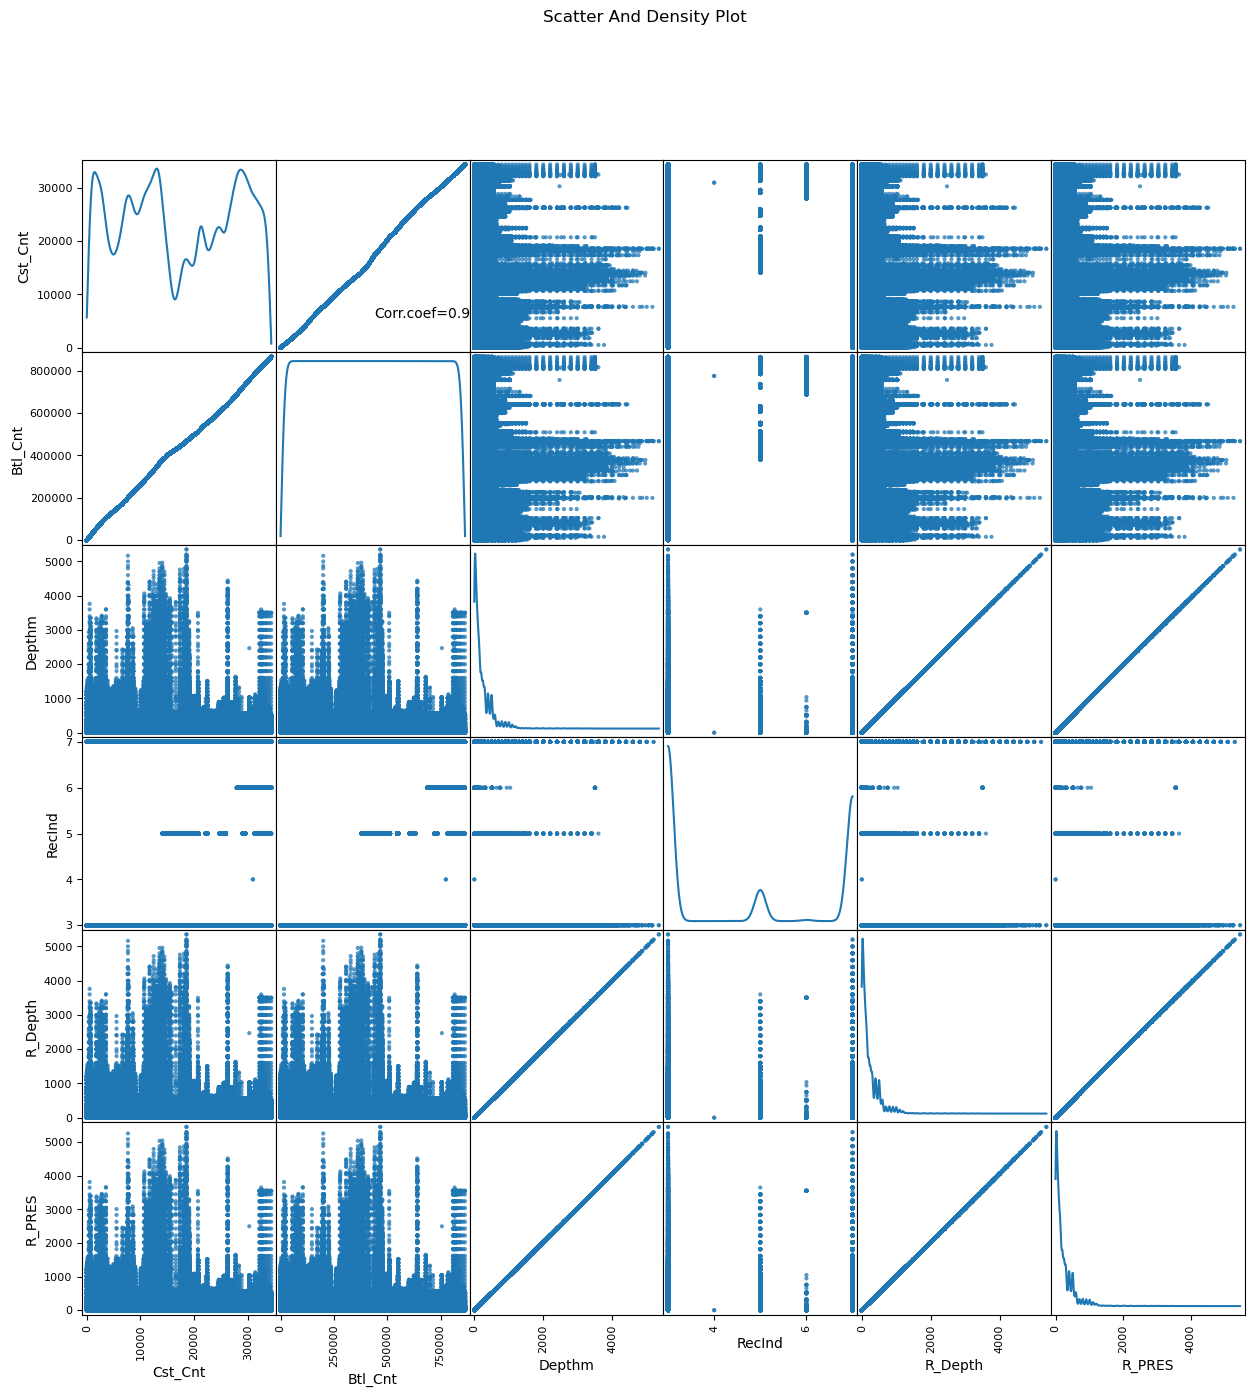

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

...

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [212]:
plotscatter(df1, 15, 10)

In [214]:
df1.describe()

,Cst_Cnt,Btl_Cnt,Depthm,T_degC,Salnty,O2ml_L,STheta,O2Sat,Oxy_µmol/Kg,BtlNum,...,R_CHLA,R_PHAEO,R_PRES,R_SAMP,DIC1,DIC2,TA1,TA2,pH2,pH1
count,864863.000000,864863.000000,864863.000000,853900.000000,817509.000000,696201.000000,812174.000000,661274.000000,661268.000000,118667.000000,...,225276.000000,225275.000000,864863.000000,122006.000000,1999.000000,224.000000,2084.000000,234.000000,10.000000,84.000000
mean,17138.790958,432432.000000,226.831951,10.799677,33.840350,3.392468,25.819394,57.103779,148.808694,10.497426,...,0.450225,0.198599,228.395694,162.071521,2153.239714,2168.148330,2256.055845,2278.858803,7.948570,7.910983
std,10240.949817,249664.587267,316.050259,4.243825,0.461843,2.073256,1.167787,37.094137,90.187533,6.189688,...,1.208566,0.376539,319.456731,85.722796,112.995202,154.852332,34.844435,58.496495,0.021216,0.077666
min,1.000000,1.000000,0.000000,1.440000,28.431000,-0.010000,20.934000,-0.100000,-0.434900,0.000000,...,-0.010000,-3.890000,0.000000,0.000000,1948.850000,1969.440000,2181.570000,2198.150000,7.923100,7.618300
25%,8269.000000,216216.500000,46.000000,7.680000,33.488000,1.360000,24.965000,21.100000,60.915470,5.000000,...,0.050000,0.050000,46.000000,200.000000,2028.330000,2008.977500,2230.322500,2229.062500,7.931475,7.898675
50%,16848.000000,432432.000000,125.000000,10.060000,33.863000,3.440000,25.996000,54.400000,151.064150,10.000000,...,0.160000,0.110000,126.000000,206.000000,2170.640000,2265.885000,2244.325000,2247.505000,7.946650,7.928850
75%,26557.000000,648647.500000,300.000000,13.880000,34.196900,5.500000,26.646000,97.600000,240.379600,16.000000,...,0.390000,0.230000,302.000000,214.000000,2253.810000,2315.525000,2278.505000,2316.452500,7.963300,7.955100
max,34404.000000,864863.000000,5351.000000,31.140000,37.034000,11.130000,250.784000,214.100000,485.701800,25.000000,...,66.110000,65.300000,5458.000000,424.000000,2367.800000,2364.420000,2434.900000,2437.000000,7.988300,8.047700


In [91]:
bottle_df=df1[['T_degC', 'Salnty']]
bottle_df.columns=['Temperature', 'Salinity']
bottle_df.head()

,Temperature,Salinity
1,10.46,33.440
2,10.46,33.437
3,10.45,33.420
4,10.45,33.421
5,10.45,33.431


/Users/steffidorothy/anaconda3/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


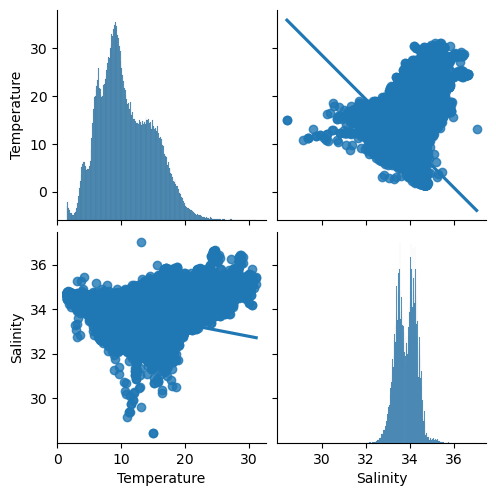

In [219]:
sns.pairplot(bottle_df, kind='reg')

/Users/steffidorothy/anaconda3/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


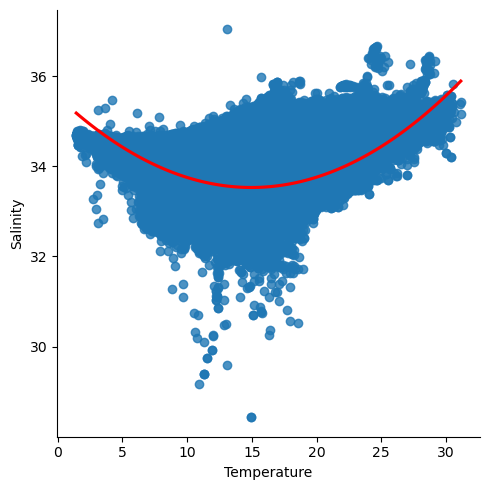

In [220]:
sns.lmplot(x='Temperature', y='Salinity', data=bottle_df, order=2, ci=None, line_kws={'color': 'red'})

In [221]:
#Correlation Coefficient
correlation=bottle_df['Salinity'].corr(bottle_df['Temperature'])
print(f'Correlation Coefficient:{correlation}')

Correlation Coefficient:-0.5052659661915726


Correlation Matrix

<Axes: >

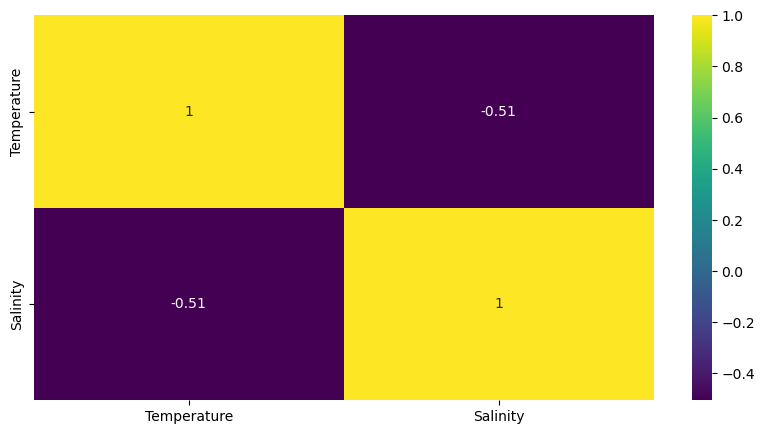

In [223]:
plt.figure(figsize=(10,5))
sns.heatmap(bottle_df.corr(numeric_only=True), cbar=True, annot=True, cmap='viridis')

Preprocessing - Data Cleaning

/var/folders/01/p9wdd6714s9db6szcr48p6pw0000gn/T/ipykernel_84809/3355895407.py:1: DtypeWarning: Columns (47,73) have mixed types. Specify dtype option on import or set low_memory=False.
  df1=pd.read_csv('/Users/steffidorothy/Downloads/KDD/project 3/bottle.csv', delimiter=',', nrows=nrowsread)


Text(0.5, 1.0, 'Fillna With Mean')

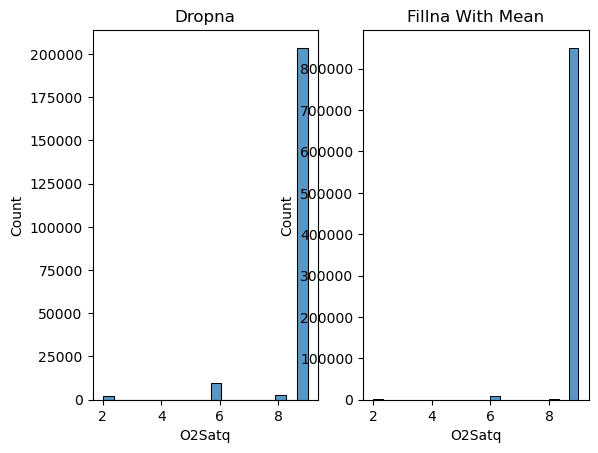

In [229]:
df1=pd.read_csv('/Users/steffidorothy/Downloads/KDD/project 3/bottle.csv', delimiter=',', nrows=nrowsread)
#Comparing Oxygen Saturation Using Fillna () with mean() vs dropna()
fig, ax=plt.subplots(1,2)
sns.histplot(df1.O2Satq.dropna(), ax=ax[0])
ax[0].set_title('Dropna')
sns.histplot(df1.O2Satq.fillna(df1.O2Satq.mean()), ax=ax[1])
ax[1].set_title('Fillna With Mean')

normalize with box-cox

Text(0.5, 1.0, 'Normalized Fillna With Mean')

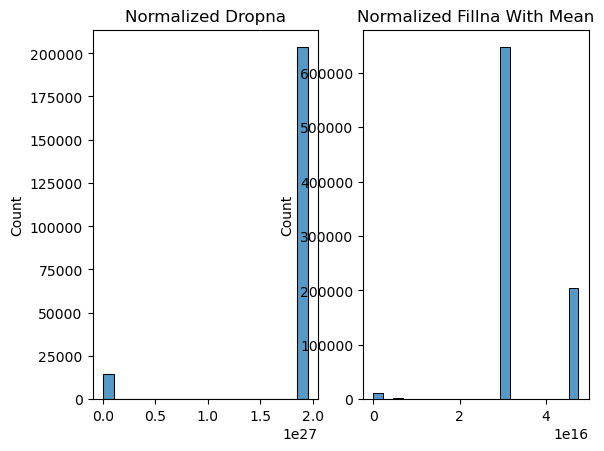

In [231]:
normalized_ox_dropna=stats.boxcox(df1.O2Satq.dropna())[0]
normalized_ox_fillna=stats.boxcox(df1.O2Satq.fillna(df1.O2Satq.mean()))[0]
fig, ax=plt.subplots(1,2)
sns.histplot(normalized_ox_dropna, ax=ax[0])
ax[0].set_title("Normalized Dropna")
sns.histplot(normalized_ox_fillna, ax=ax[1])
ax[1].set_title("Normalized Fillna With Mean")

Text(0.5, 1.0, 'Fillna With Mean')

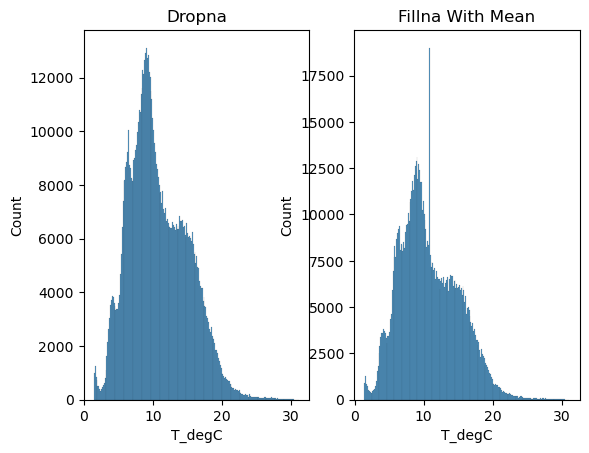

In [232]:
#Comparing Temperature Using fillna() with mean()Vs dropna()
fig, ax=plt.subplots(1,2)
sns.histplot(df1.T_degC.dropna(), ax=ax[0])
ax[0].set_title('Dropna')
sns.histplot(df1.T_degC.fillna(df1.T_degC.mean()), ax=ax[1])
ax[1].set_title('Fillna With Mean')

Both the graphs are not so different, best using .fillna(), as using .dropna() could lead to errors if we are going to correlate variables.

Nan Values Visualization

<Axes: >

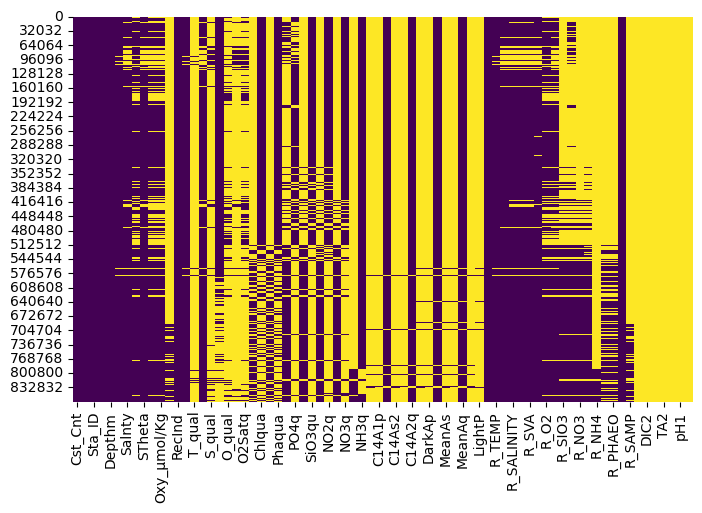

In [716]:
plt.rcParams['figure.figsize']=(8,5)
sns.heatmap(df1.isna(), cbar=False, cmap='viridis')

In [16]:
#Calculate the percentage of missing values in each column
m=df1.isnull().mean()*100
#Set a threshold
t=50
#Identify the columns with high missing values
h=m[m>t].index.tolist()
print('Columns with high missing values')
print(h)

Columns with high missing values
['BtlNum', 'T_qual', 'S_qual', 'O_qual', 'SThtaq', 'O2Satq', 'ChlorA', 'Phaeop', 'PO4uM', 'SiO3uM', 'NO2uM', 'NO3uM', 'NH3uM', 'C14As1', 'C14A1p', 'C14As2', 'C14A2p', 'DarkAs', 'DarkAp', 'MeanAs', 'MeanAp', 'IncTim', 'LightP', 'R_SIO3', 'R_PO4', 'R_NO3', 'R_NO2', 'R_NH4', 'R_CHLA', 'R_PHAEO', 'R_SAMP', 'DIC1', 'DIC2', 'TA1', 'TA2', 'pH2', 'pH1', 'DIC Quality Comment']


In [18]:
#Remove columns that have high missing values
c=['O2ml_L', 'O2Sat', 'Oxy_µmol/Kg', 'R_Depth', 'R_POTEMP', 'R_DYNHT', 'R_O2', 'R_O2Sat', 'T_qual', 'S_qual', 'O_qual', 'SThtaq', 'O2Satq', 'ChlorA', 'Phaeop', 'PO4uM', 'SiO3uM', 'NO2uM', 'NO3uM', 'NH3uM', 'C14As1', 'C14A1p', 'C14As2', 'C14A2p', 'DarkAs', 'DarkAp', 'MeanAs', 'MeanAp', 'LightP', 'R_SIO3', 'R_PO4', 'R_NO3', 'R_NO2', 'R_NH4', 'R_CHLA', 'R_PHAEO', 'R_SAMP', 'DIC1', 'DIC2', 'TA1', 'TA2', 'pH2', 'pH1']
df1=df1.drop(columns=c)

<Axes: >

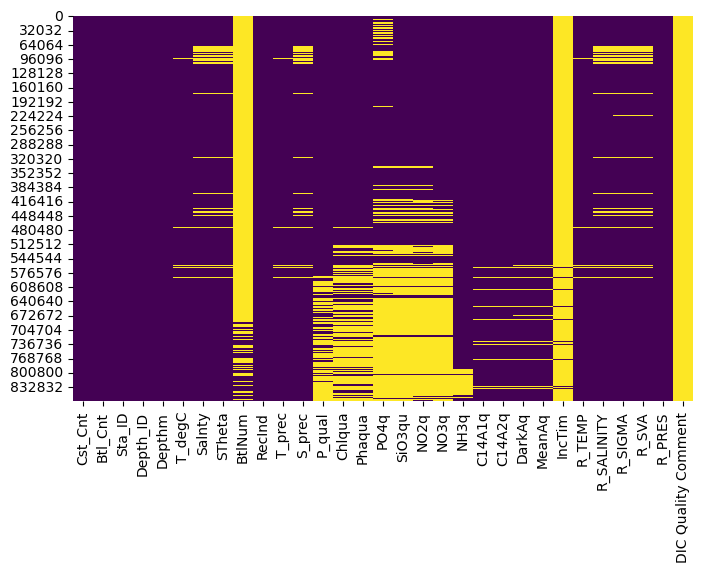

In [26]:
df1=df1.reset_index(drop=True)
plt.rcParams["figure.figsize"] = (8,5)
sns.heatmap(df1.isna(),cbar=False,cmap='viridis')

In [20]:
numeric_df = df1.select_dtypes(include=np.number)
df1[numeric_df.columns] = numeric_df.fillna(numeric_df.mean())

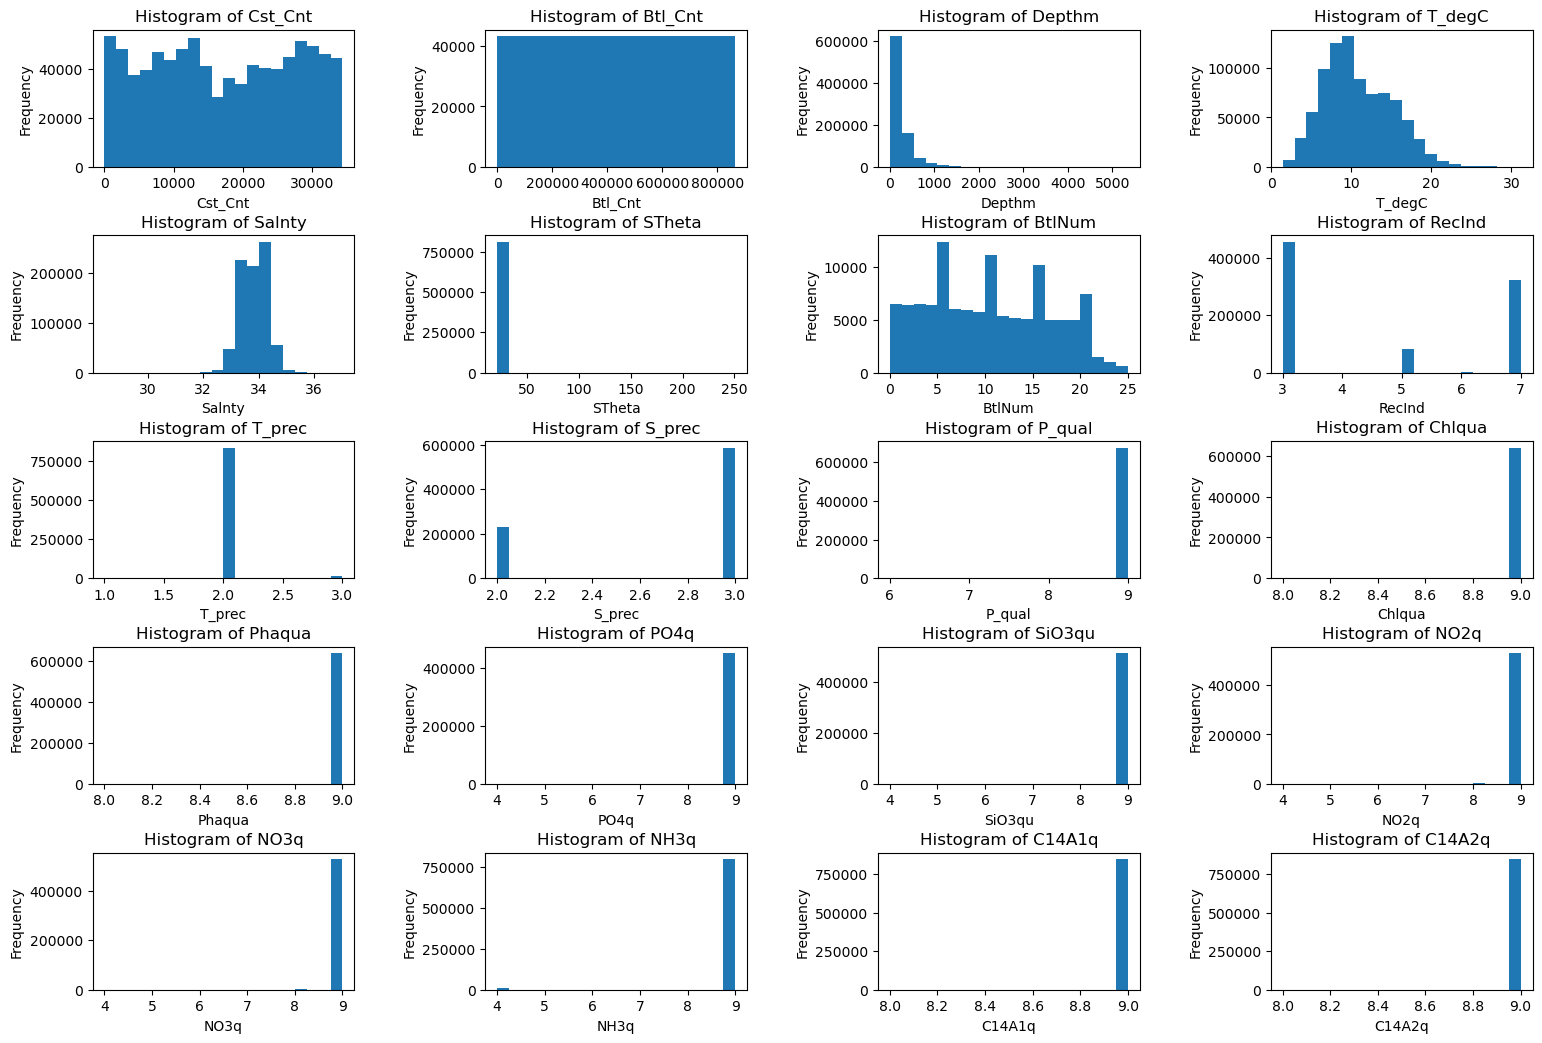

In [28]:
num_cols_to_plot = 20
n_rows = int(np.ceil(num_cols_to_plot / 4))
n_cols = min(4, num_cols_to_plot)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 12))
axes_flat = axes.ravel()
for i in range(num_cols_to_plot):
    if i >= len(axes_flat):
        break
    column = numeric_df.columns[i]
    ax = axes_flat[i]
    ax.hist(numeric_df[column], bins=20)
    ax.set_title(f'Histogram of {column}')
    ax.set_xlabel(column)
    ax.set_ylabel('Frequency')
plt.subplots_adjust(left=0.05, right=0.95, top=0.9, bottom=0.1, wspace=0.5, hspace=0.5)
plt.show()

In [22]:
df1 = df1.select_dtypes(exclude=['object'])
print(df1)

        Cst_Cnt  Btl_Cnt  Depthm  T_degC   Salnty    STheta     BtlNum  \
0             1        1       0  10.500  33.4400  25.64900  10.497426   
1             1        2       8  10.460  33.4400  25.65600  10.497426   
2             1        3      10  10.460  33.4370  25.65400  10.497426   
3             1        4      19  10.450  33.4200  25.64300  10.497426   
4             1        5      20  10.450  33.4210  25.64300  10.497426   
...         ...      ...     ...     ...      ...       ...        ...   
864858    34404   864859       0  18.744  33.4083  23.87055  10.497426   
864859    34404   864860       2  18.744  33.4083  23.87072   4.000000   
864860    34404   864861       5  18.692  33.4150  23.88911   3.000000   
864861    34404   864862      10  18.161  33.4062  24.01426   2.000000   
864862    34404   864863      15  17.533  33.3880  24.15297   1.000000   

        RecInd  T_prec  S_prec  ...      NH3q  C14A1q  C14A2q  DarkAq  MeanAq  \
0            3     1.0     2.0

Null Values

In [93]:
bottle_df.isnull().sum()

Temperature    0
Salinity       0
dtype: int64

In [24]:
# Statistical method: Z-score
from scipy.stats import zscore
numeric_df = df1.select_dtypes(include=["number"])
z_scores = numeric_df.apply(zscore)

# Set a threshold for identifying outliers
threshold = 5

# Identify rows without outliers (absolute Z-score < threshold for all columns)
df1 = df1[(z_scores.abs() < threshold).all(axis=1)]

print("Data without outliers:")
print(df1)

Data without outliers:
        Cst_Cnt  Btl_Cnt  Depthm  T_degC   Salnty    STheta     BtlNum  \
1             1        2       8  10.460  33.4400  25.65600  10.497426   
2             1        3      10  10.460  33.4370  25.65400  10.497426   
3             1        4      19  10.450  33.4200  25.64300  10.497426   
4             1        5      20  10.450  33.4210  25.64300  10.497426   
5             1        6      30  10.450  33.4310  25.65100  10.497426   
...         ...      ...     ...     ...      ...       ...        ...   
864795    34402   864796       0  19.390  33.3005  23.62476  10.497426   
864827    34403   864828       0  19.556  33.2875  23.57227  10.497426   
864858    34404   864859       0  18.744  33.4083  23.87055  10.497426   
864861    34404   864862      10  18.161  33.4062  24.01426   2.000000   
864862    34404   864863      15  17.533  33.3880  24.15297   1.000000   

        RecInd  T_prec  S_prec  ...      NH3q  C14A1q  C14A2q  DarkAq  MeanAq  \
1      

In [25]:
if df1.select_dtypes(include=[int, float]).shape[1] == df1.shape[1]:
    print("All columns are numeric")
else:
    print("The DataFrame contains non-numeric data")

All columns are numeric


In [28]:
# Find non-numeric values in the DataFrame
non_numeric = df1.applymap(lambda x: not pd.to_numeric(x, errors='coerce')).any()
print("Columns with non-numeric values:")
print(df1.columns[non_numeric])

Columns with non-numeric values:
Index(['Depthm', 'BtlNum', 'R_PRES'], dtype='object')


In [29]:
# Strip whitespace and remove unwanted characters (like extra spaces)
df1 = df1.applymap(lambda x: x.strip() if isinstance(x, str) else x)
df1 = df1.replace(r'^\s*$', float('NaN'), regex=True)  # Replace empty strings with NaN
df1 = df1.apply(lambda col: pd.to_numeric(col, errors='coerce')).dropna()

In [30]:
# Attempt to convert all columns to numeric, coercing errors to NaN
df1 = df1.apply(lambda col: pd.to_numeric(col, errors='coerce'))
if df1.isna().any().any():
    print("There were non-numeric values that could not be converted.")
    df1 = df1.dropna()
else:
    print("All values are successfully converted to numeric.")

All values are successfully converted to numeric.


In [31]:
df1.isnull().sum()

Cst_Cnt       0
Btl_Cnt       0
Depthm        0
T_degC        0
Salnty        0
STheta        0
BtlNum        0
RecInd        0
T_prec        0
S_prec        0
P_qual        0
Chlqua        0
Phaqua        0
PO4q          0
SiO3qu        0
NO2q          0
NO3q          0
NH3q          0
C14A1q        0
C14A2q        0
DarkAq        0
MeanAq        0
R_TEMP        0
R_SALINITY    0
R_SIGMA       0
R_SVA         0
R_PRES        0
dtype: int64

In [22]:
df1.head

<bound method NDFrame.head of         Cst_Cnt  Btl_Cnt  Depthm  T_degC   Salnty    STheta     BtlNum  \
0             1        1       0  10.500  33.4400  25.64900  10.497426   
1             1        2       8  10.460  33.4400  25.65600  10.497426   
2             1        3      10  10.460  33.4370  25.65400  10.497426   
3             1        4      19  10.450  33.4200  25.64300  10.497426   
4             1        5      20  10.450  33.4210  25.64300  10.497426   
...         ...      ...     ...     ...      ...       ...        ...   
864858    34404   864859       0  18.744  33.4083  23.87055  10.497426   
864859    34404   864860       2  18.744  33.4083  23.87072   4.000000   
864860    34404   864861       5  18.692  33.4150  23.88911   3.000000   
864861    34404   864862      10  18.161  33.4062  24.01426   2.000000   
864862    34404   864863      15  17.533  33.3880  24.15297   1.000000   

        RecInd  T_prec  S_prec  ...      NH3q  C14A1q  C14A2q  DarkAq  MeanAq  \


In [36]:
df1= df1.iloc[0:200000,:]

In [38]:
df1.shape

(200000, 27)

Model Selection, Training, and Optimization 

In [264]:
#Choosing features
X = np.array(bottle_df['Salinity']).reshape(-1, 1)
y = np.array(bottle_df['Temperature']).reshape(-1, 1)

Linear Regression

In [79]:
from sklearn.linear_model import LinearRegression

In [270]:
df1["R_Depth"] = np.log1p(df1["R_Depth"])

In [272]:
df.columns

Index(['Cst_Cnt', 'Btl_Cnt', 'Depthm', 'T_degC', 'Salnty', 'STheta', 'RecInd',
       'T_prec', 'S_prec', 'NH3q', 'C14A1q', 'C14A2q', 'DarkAq', 'MeanAq',
       'R_Depth', 'R_TEMP', 'R_POTEMP', 'R_SALINITY', 'R_SIGMA', 'R_SVA',
       'R_DYNHT', 'R_PRES'],
      dtype='object')

In [282]:
# Extract the target and remove from columns
# Observe columns variable is old now as we updated df
y = df[["T_degC"]]
df.drop(columns=["T_degC"], inplace=True)
X = df
X_train, X_val, t_train, t_val = train_test_split(X, y, test_size=0.2, random_state=17)

In [286]:
X_train.shape, t_train.shape, X_val.shape, t_val.shape

((12321414, 1), (586734, 1), (146684, 21), (146684, 1))

In [292]:
# let's define function to scale the input data without data leakage
#Data Normalization
def transform_train_val(X_train, X_val):
    # define the scaler
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    # scale the validation data by the x_train_transformer
    X_val_scaled = scaler.transform(X_val)

    return X_train_scaled, X_val_scaled

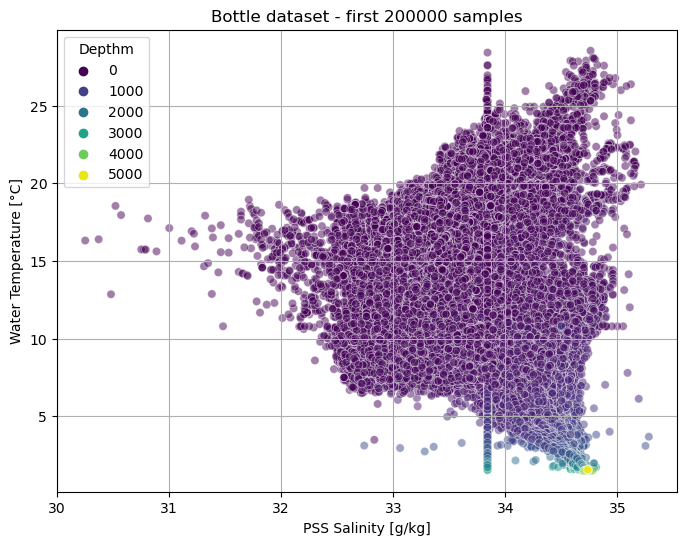

In [860]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df1, x='Salnty', y='T_degC', hue='Depthm', palette='viridis', alpha=0.5)
plt.grid()
plt.xlabel('PSS Salinity [g/kg]')
plt.ylabel('Water Temperature [°C]')
plt.title('Bottle dataset - first 200000 samples')
plt.show()

In [40]:
X = df1.drop(columns=['T_degC'])
y = df1['T_degC']

In [44]:
r_2_train = np.empty(4, dtype=object) 
r_2_test = np.empty(4, dtype=object) 
mse = np.empty(4, dtype=object) 
mae = np.empty(4, dtype=object) 
rmse=np.empty(4, dtype=object)

In [42]:
r_2_train = [0, 0, 0 ,0, 0]
r_2_test = [0, 0, 0, 0 ,0]
mse = [0, 0, 0, 0 ,0]
mae = [0, 0, 0, 0 ,0]
rmse=[0, 0, 0, 0 ,0]

In [48]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state=1)
X_train = np.array(X_train).reshape(-1,1)
y_train = np.array(y_train).reshape(-1,1)
X_test = np.array(X_test).reshape(-1,1)
y_test = np.array(y_test).reshape(-1,1)

In [130]:
lr = LinearRegression()
lr.fit(X_train,y_train)
y_pred_lr = lr.predict(X_test)
r_2_train[0] = lr.score(X_train,y_train)
r_2_test[0] = lr.score(X_test,y_test)
mse[0] = mean_squared_error(y_test, y_pred_lr)
mae[0] = mean_absolute_error(y_test, y_pred_lr)
rmse[0] = np.sqrt(mse[0])
coef = lr.coef_
intercept = lr.intercept_
print("Root Mean Squared Error:", rmse[0])
print('\nR2 train score:', r_2_train[0])
print('\nR2 test score:', r_2_test[0])
print('\nMean Squared Error:', mse[0])
print('\nMean Absolute Error:', mae[0])
print('\nCoefficients:',coef[0])
print('\nIntercept:', intercept)

Root Mean Squared Error: 2.95347037087938e-15

R2 train score: 1.0

R2 test score: 1.0

Mean Squared Error: 8.722987231662383e-30

Mean Absolute Error: 2.2564172752481683e-15

Coefficients: -8.249067597826794e-19

Intercept: 0.002398961960720314


In [83]:
X_test_ordered = np.sort(X_test, axis=0)
index = np.argsort(X_test, axis=0).reshape(-1)
y_pred_lr_ordered = y_pred_lr[index]

In [97]:
bottle=df1

In [314]:
#Predict values outside X range
x_1 = np.array([[30,31,32,33,34,35,36,37,38]])
x_1 = x_1.reshape(-1, 1)
y_pred_lr_1 = lr.predict(x_1)
y_pred_lr_1

array([[ 30.59353372],
       [ 25.26866121],
       [ 19.94378869],
       [ 14.61891618],
       [  9.29404367],
       [  3.96917116],
       [ -1.35570135],
       [ -6.68057386],
       [-12.00544637]])

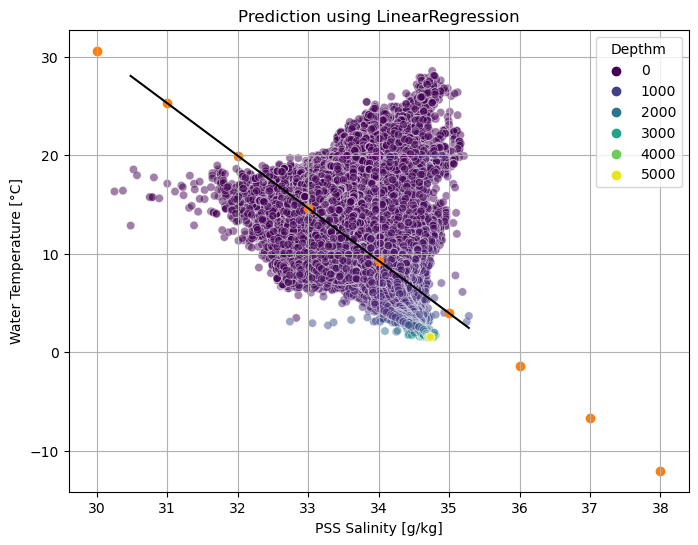

In [315]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=bottle, x='Salnty', y='T_degC', hue='Depthm', palette='viridis', alpha=0.5)
plt.plot(X_test_ordered, y_pred_lr_ordered, label="Linear regression", color='k')
plt.scatter(x_1, y_pred_lr_1)
plt.grid()
plt.xlabel('PSS Salinity [g/kg]')
plt.ylabel('Water Temperature [°C]')
plt.title('Prediction using LinearRegression')
plt.show()

Based on the provided scatter plot, there appears to be a negative correlation between water salinity and water temperature. This means that as salinity increases, water temperature tends to decrease.  it is possible to predict water temperature based on salinity using a linear regression model.

Best parameters: {'fit_intercept': True}
Cross-Validation Mean Squared Error: 2.0883658341252497e-29

R2 train score: 1.0

R2 test score: 1.0

Mean Squared Error: 8.722987231662383e-30

Mean Absolute Error: 2.2564172752481683e-15

Coefficients: [-8.24906760e-19  2.20228566e-20  3.21622495e-16  5.53338879e-13
 -1.25772997e-15 -3.35802029e-29 -4.28556996e-16 -1.19948098e-03
 -4.45409189e-16  0.00000000e+00  8.67361738e-19 -2.71050543e-19
  7.89800814e-14  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  1.00000000e+00 -5.52649299e-13  2.91909080e-15
 -2.47979454e-17 -3.14677274e-16]

Intercept: 0.002398961960720314


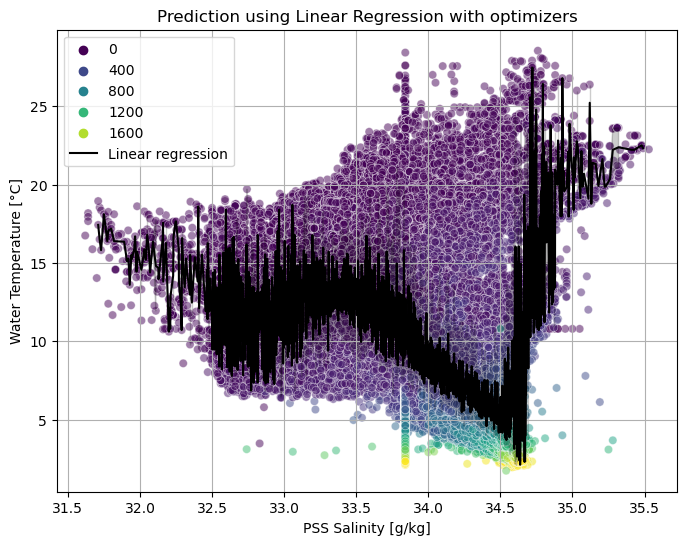

In [184]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
lr = LinearRegression()
param_grid = {
    'fit_intercept': [True, False],  # Whether to fit the intercept
}
grid_search = GridSearchCV(lr, param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_train)

# Best model from grid search
best_model = grid_search.best_estimator_
print("Best parameters:", grid_search.best_params_)
cv_scores = cross_val_score(best_model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
mean_cv_score = np.mean(cv_scores)
print(f'Cross-Validation Mean Squared Error: {-mean_cv_score}')
y_pred = best_model.predict(X_test)
r_2_train = best_model.score(X_train, y_train)
r_2_test = best_model.score(X_test, y_test)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
coef = best_model.coef_
intercept = best_model.intercept_

print('\nR2 train score:', r_2_train)
print('\nR2 test score:', r_2_test)
print('\nMean Squared Error:', mse)
print('\nMean Absolute Error:', mae)
print('\nCoefficients:', coef)
print('\nIntercept:', intercept)
plt.figure(figsize=(8, 6))
sns.scatterplot(data=bottle, x='Salnty', y='T_degC', hue='Depthm', palette='viridis', alpha=0.5)
sns.lineplot(x=X_test['Salnty'], y=y_pred, color='k', label="Linear regression")
plt.grid()
plt.xlabel('PSS Salinity [g/kg]')
plt.ylabel('Water Temperature [°C]')
plt.title('Prediction using Linear Regression with optimizers')
plt.legend()
plt.show()

# Predicting values outside the X range
# Use Depthm = 0 for prediction
x_1 = np.array([[30, 0], [31, 0], [32, 0], [33, 0], [34, 0], [35, 0], [36, 0], [37, 0], [38, 0]])

# Make predictions for these new values
y_pred_1 = best_model.predict(x_1)

# Plotting the predictions outside the range
plt.figure(figsize=(8, 6))
sns.scatterplot(data=bottle_df, x='Salinity', y='Temperature', hue='Depthm', palette='viridis', alpha=0.5)
sns.lineplot(x=X_test['Salnty'], y=y_pred, color='k', label="Linear regression")
plt.scatter(x_1[:, 0], y_pred_1, color='red', label='Predictions for new values')
plt.grid()
plt.xlabel('PSS Salinity [g/kg]')
plt.ylabel('Water Temperature [°C]')
plt.title('Prediction using Linear Regression with Optimizers, Grid Search, and Cross Validation')
plt.legend()
plt.show()


ExactExplainer explainer: 130933it [02:29, 857.72it/s]                          


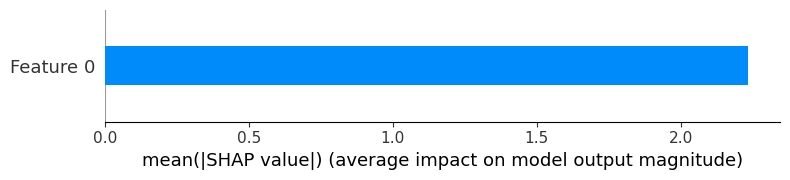

Feature ranking:
1. feature 0 (0.733688)


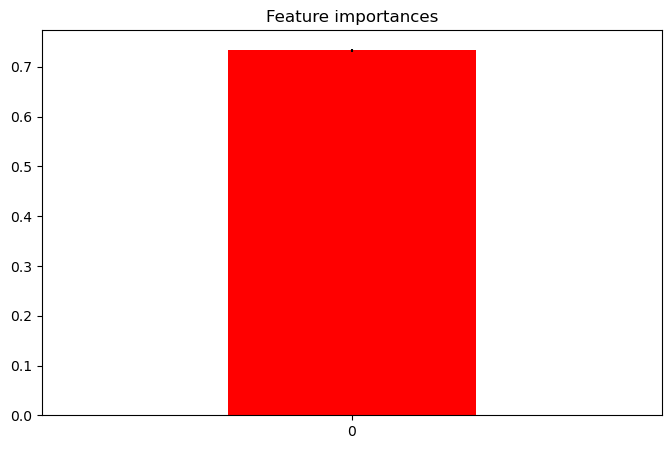

In [317]:
explainer = shap.Explainer(lr.predict, X_train)  
shap_values = explainer(X_train)

# Summary plot for feature importance
shap.summary_plot(shap_values, X_train, plot_type="bar")

# Feature importance using Permutation Feature Importance
from sklearn.inspection import permutation_importance

result = permutation_importance(
    lr, X_train, y_train, n_repeats=10, random_state=42, n_jobs=2
)

# Get feature importances and their standard deviations
importances = result.importances_mean
std = result.importances_std
indices = np.argsort(importances)[::-1]
print("Feature ranking:")
for f in range(X_train.shape[1]):
    print(
        "%d. feature %d (%f)" % (f + 1, indices[f], importances[indices[f]])
    )

# Plot feature importances
plt.figure()
plt.title("Feature importances")
plt.bar(
    range(X_train.shape[1]),
    importances[indices],
    color="r",
    yerr=std[indices],
    align="center",
)
plt.xticks(range(X_train.shape[1]), indices)
plt.xlim([-1, X_train.shape[1]])
plt.show()

In [324]:
explainer=LimeTabularExplainer(X_train, mode='regression')
explanation=explainer.explain_instance(X_train[0], lr.predict)
print(explanation.as_list())

[('0 > 34.32', -4.277802432321509)]


Polynomial Regression

In [65]:
X = df1.drop(columns=['T_degC'])
y = df1['T_degC']
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)
X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(X_poly, y, test_size=0.2, random_state=1)

In [132]:
from sklearn.linear_model import LinearRegression
lr_poly = LinearRegression()
lr_poly.fit(X_train_poly, y_train_poly)
y_pred_lr_poly = lr_poly.predict(X_test_poly)

r_2_train[1] = lr_poly.score(X_train_poly,y_train_poly)
r_2_test[1] = lr_poly.score(X_test_poly,y_test_poly)
mse[1] = mean_squared_error(y_test_poly, y_pred_lr_poly)
mae[1] = mean_absolute_error(y_test_poly, y_pred_lr_poly)
rmse[1] = np.sqrt(mse[1])
coef = lr_poly.coef_
intercept = lr_poly.intercept_
print("Root Mean Squared Error:", rmse[1])
print('\nR2 train score:', r_2_train[1])
print('\nR2 test score:', r_2_test[1])
print('\nMean Squared Error:', mse[1])
print('\nMean Absolute Error:', mae[1])
print('\nCoefficients:',coef[1])
print('\nIntercept:', intercept)

Root Mean Squared Error: 6.29667382936973e-07

R2 train score: 0.9999999999999789

R2 test score: 0.999999999999979

Mean Squared Error: 3.964810131346965e-13

Mean Absolute Error: 4.234373600146113e-07

Coefficients: 5.588413701361703e-09

Intercept: -0.0017539598406024481


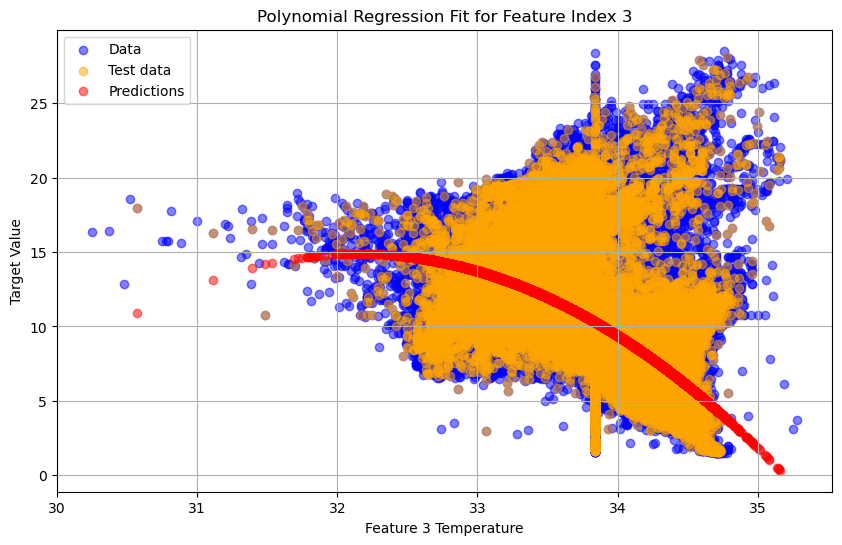

In [908]:
feature_index = 3
x_feature = X.iloc[:, feature_index].values.reshape(-1, 1)
x_feature_poly = poly.fit_transform(x_feature)
X_train_feature, X_test_feature, y_train_feature, y_test_feature = train_test_split(x_feature_poly, y, test_size=0.2, random_state=1)
lr_poly_feature = LinearRegression()
lr_poly_feature.fit(X_train_feature, y_train_feature)
y_pred_feature = lr_poly_feature.predict(X_test_feature)
plt.figure(figsize=(10, 6))
plt.scatter(x_feature, y, color='blue', label='Data', alpha=0.5)
plt.scatter(X_test_feature[:, 1], y_test_feature, color='orange', label='Test data', alpha=0.5)
plt.scatter(X_test_feature[:, 1], y_pred_feature, color='red', label='Predictions', alpha=0.5)
plt.title("Polynomial Regression Fit for Feature Index {}".format(feature_index), +' Temperature')
plt.xlabel("Feature {}".format(feature_index)+' Temperature')
plt.ylabel("Target Value")
plt.legend()
plt.grid()
plt.show()

Regularization with Ridge Regression

In [911]:
from sklearn.linear_model import Ridge
alpha = 1.0
ridge_model = Ridge(alpha=alpha)
ridge_model.fit(X_train_poly, y_train_poly)
y_pred_ridge = ridge_model.predict(X_test_poly)
r_2_test_ridge = ridge_model.score(X_test_poly, y_test_poly)
mse_ridge = mean_squared_error(y_test_poly, y_pred_ridge)
mae_ridge = mean_absolute_error(y_test_poly, y_pred_ridge)
rmse = np.sqrt(mse_ridge)
print("\nRidge Regression Results:")
print(f"R2 test score: {r_2_test_ridge}")
print(f"Mean Squared Error: {mse_ridge}")
print(f"Mean Absolute Error: {mae_ridge}")
print("Root Mean Squared Error:", rmse)


Ridge Regression Results:
R2 test score: 0.9999704550041659
Mean Squared Error: 0.0005497862692581622
Mean Absolute Error: 0.00012791769985688419
Root Mean Squared Error: 0.02344752160161415


Regularization with Lasso Regression

In [58]:
from sklearn.linear_model import Lasso
lasso_model = Lasso(alpha=0.1)  # Adjust alpha for regularization strength
lasso_model.fit(X_train_poly, y_train_poly)
y_pred_lasso = lasso_model.predict(X_test_poly)
r_2_test_lasso = lasso_model.score(X_test_poly, y_test_poly)
mse_lasso = mean_squared_error(y_test_poly, y_pred_lasso)
mae_lasso = mean_absolute_error(y_test_poly, y_pred_lasso)
rmse = np.sqrt(mse_lasso)
print("\nLasso Regression Results:")
print(f"R2 test score: {r_2_test_lasso}")
print(f"Mean Squared Error: {mse_lasso}")
print(f"Mean Absolute Error: {mae_lasso}")
print("Root Mean Squared Error:", rmse)

/Users/steffidorothy/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.649e+02, tolerance: 2.952e+02
  model = cd_fast.enet_coordinate_descent(



Lasso Regression Results:
R2 test score: 0.9999801279620248
Mean Squared Error: 0.00036978761758060894
Mean Absolute Error: 0.010417139830251299
Root Mean Squared Error: 0.019229862651111394


In [53]:
from sklearn.linear_model import ElasticNet
elastic_net = ElasticNet(alpha=0.1, l1_ratio=0.5)  # You can adjust alpha and l1_ratio
elastic_net.fit(X_train_poly, y_train_poly)

# Predict using the test set
y_pred_elastic_net = elastic_net.predict(X_test_poly)

r_2_train = elastic_net.score(X_train_poly, y_train_poly)
r_2_test = elastic_net.score(X_test_poly, y_test_poly)
mse = mean_squared_error(y_test_poly, y_pred_elastic_net)
mae = mean_absolute_error(y_test_poly, y_pred_elastic_net)
rmse = np.sqrt(mse)

print("Elastic Net Regression Results:")
print("Root Mean Squared Error:", rmse)
print('\nR2 train score:', r_2_train)
print('\nR2 test score:', r_2_test)
print('\nMean Squared Error:', mse)
print('\nMean Absolute Error:', mae)

/Users/steffidorothy/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.432e+02, tolerance: 2.952e+02
  model = cd_fast.enet_coordinate_descent(


Elastic Net Regression Results:
Root Mean Squared Error: 0.018162437065909087

R2 train score: 0.9999807277914193

R2 test score: 0.9999822728757496

Mean Squared Error: 0.0003298741201731083

Mean Absolute Error: 0.010800543799711097


LIME

In [58]:
explainer=LimeTabularExplainer(X_train_poly, mode='regression')
explanation=explainer.explain_instance(X_train_poly[3], lr_poly.predict)
#Print the explanation
print(explanation.as_list())

[('56 > 1575823.66', -378.975648313421), ('78 > 15431.20', -156.09103031018222), ('97 > 15431.17', 144.2973932497912), ('123 > 15535.88', 133.358585575997), ('370 > 15535.88', -130.30849107452156), ('62 > 1351037.25', 47.59937644323035), ('61 > 1351037.25', 43.06114983303653), ('68 > 1351037.25', 42.37827566002586), ('67 > 1351037.25', 41.75432413967759), ('65 > 1351037.25', 41.374425734890686)]


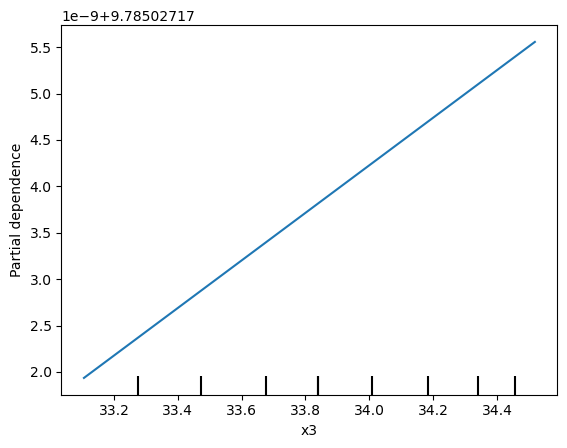

In [214]:
from sklearn.inspection import PartialDependenceDisplay

# Create the PDP plot
PartialDependenceDisplay.from_estimator(lr_poly, X_test_poly, features=[3])
plt.show()

Decision Tree Regression

In [55]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state=1)
X_train = np.array(X_train).reshape(-1,1)
y_train = np.array(y_train).reshape(-1,1)
X_test = np.array(X_test).reshape(-1,1)
y_test = np.array(y_test).reshape(-1,1)

In [229]:
from sklearn.tree import DecisionTreeRegressor
dtr = DecisionTreeRegressor(max_depth=3, max_leaf_nodes=9)
# split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)
dtr.fit(X_train,y_train)
y_pred_dt = dtr.predict(X_test)

r_2_train[2] = dtr.score(X_train,y_train)
r_2_test[2] = dtr.score(X_test,y_test)
mse[2] = mean_squared_error(y_test, y_pred_dt)
mae[2] = mean_absolute_error(y_test, y_pred_dt)
rmse[2] = np.sqrt(mse[2])
print("Root Mean Squared Error:", rmse[2])
print('\nR2 train score:', r_2_train[2])
print('\nR2 test score:', r_2_test[2])
print('\nMean Squared Error:', mse[2])
print('\nMean Absolute Error:', mae[2])

Root Mean Squared Error: 0.6930352169045046

R2 train score: 0.9740969968332702

R2 test score: 0.9745355764545813

Mean Squared Error: 0.48029781186987386

Mean Absolute Error: 0.5576632058748698


In [59]:
dt_predict=dtr.predict(X_train)
dt_predict.mean()

9.775509443579871

In [69]:
predictions=dtr.predict(X_test)
mse=mean_squared_error(y_test, predictions)
print(f'Mean Squared Error:{mse}')

Mean Squared Error:0.48029781186987514


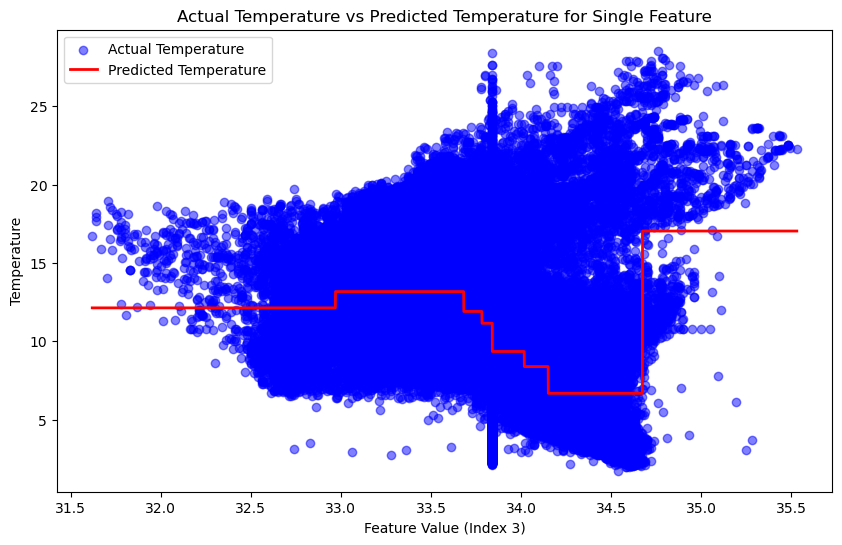

In [89]:
feature_index = 3  # Change this index as needed
x_feature = X.iloc[:, feature_index].values.reshape(-1, 1)

# Fit a new Decision Tree Regressor on just the selected feature
dtr_single_feature = DecisionTreeRegressor(max_depth=3, max_leaf_nodes=9)
dtr_single_feature.fit(x_feature, y)

# Sort values for a smooth line plot
x_feature_sorted_indices = np.argsort(x_feature, axis=0).flatten()
x_feature_sorted = x_feature[x_feature_sorted_indices]

# Predict based on sorted values of the selected feature
y_pred_line = dtr_single_feature.predict(x_feature_sorted)
plt.figure(figsize=(10, 6))
plt.scatter(x_feature, y, color='blue', label='Actual Temperature', alpha=0.5)
plt.plot(x_feature_sorted, y_pred_line, color='red', linewidth=2, label='Predicted Temperature')
plt.xlabel(f'Feature Value (Index {feature_index})')
plt.ylabel('Temperature')
plt.title('Actual Temperature vs Predicted Temperature for Single Feature')
plt.legend()
plt.show()

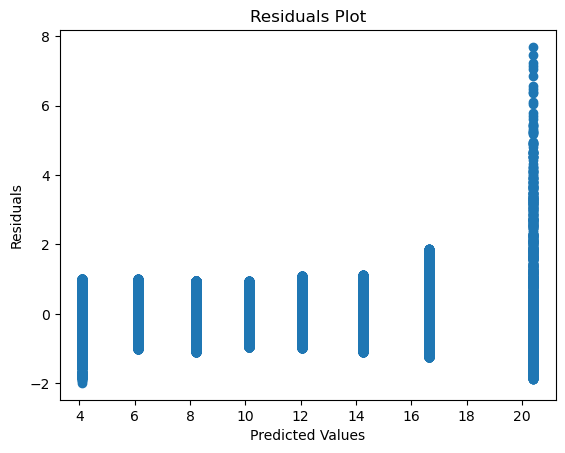

In [91]:
#Residual Analysis
residuals=y_test-predictions
plt.scatter(predictions, residuals)
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals Plot')
plt.show()

Optimization - Hyperparameter Tuning: GridSearchCV

In [216]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'max_depth': [2, 3, 4, 5, 6],
    'max_leaf_nodes': [5, 7, 9, 12],
    'min_samples_split': [2, 5, 10]
}

# Set up the GridSearchCV with 5-fold cross-validation
grid_search = GridSearchCV(
    DecisionTreeRegressor(),
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error' 
)

# Fit the grid search to the training data
grid_search.fit(X_train, y_train)
print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validated MSE: ", -grid_search.best_score_)

Best parameters found:  {'max_depth': 5, 'max_leaf_nodes': 12, 'min_samples_split': 10}
Best cross-validated MSE:  0.25893944940215935


In [ ]:
Optimization - Hyperparameter Tuning: RandomizedSearchCV

In [219]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
param_dist = {
    'max_depth': randint(2, 10),
    'max_leaf_nodes': randint(5, 15),
    'min_samples_split': randint(2, 15)
}

# Set up the RandomizedSearchCV
random_search = RandomizedSearchCV(
    DecisionTreeRegressor(),
    param_distributions=param_dist,
    n_iter=50,  # Number of parameter settings sampled
    cv=5,
    scoring='neg_mean_squared_error',
    random_state=0
)
random_search.fit(X_train, y_train)
print("Best parameters found: ", random_search.best_params_)
print("Best cross-validated MSE: ", -random_search.best_score_)

Best parameters found:  {'max_depth': 7, 'max_leaf_nodes': 14, 'min_samples_split': 2}
Best cross-validated MSE:  0.18526098762790255


Optimization with Hyperparameter Tuning - Added Polynomial Features

In [239]:
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
dtr = DecisionTreeRegressor(max_depth=3, max_leaf_nodes=9)
dtr.fit(X_train_poly, y_train)
X_test_poly = poly.transform(X_test)
y_pred_dt = dtr.predict(X_test_poly)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_test = r2_score(y_test, y_pred_dt)
mae = mean_absolute_error(y_test, y_pred_dt)

print("Root Mean Squared Error:", rmse)
print('\nR2 test score:', r2_test)
print('\nMean Absolute Error:', mae)

Root Mean Squared Error: 0.693035216904507

R2 test score: 0.9745355764545811

Mean Absolute Error: 0.5576632058748738


Model Predictions for Decision tree regression model using SHAP

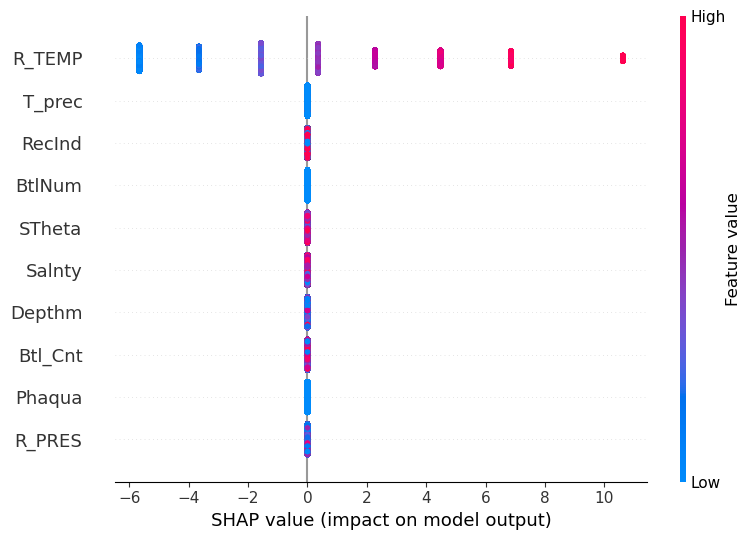

In [233]:
# Calculate mean absolute SHAP values for each feature
feature_importance = np.abs(shap_values).mean(0)

# Sort features by importance and select top 10
top_10_features = feature_importance.argsort()[-10:][::-1]
top_10_feature_names = X_test.columns[top_10_features]

# Filter SHAP values and X_test
shap_values_top10 = shap_values[:, top_10_features]
X_test_top10 = X_test[top_10_feature_names]
shap.summary_plot(shap_values_top10, X_test_top10, feature_names=top_10_feature_names)

In [ ]:
Model Predictions for Decision tree regression model using LIME

In [237]:
from lime.lime_tabular import LimeTabularExplainer
explainer = LimeTabularExplainer(X_train.values, feature_names=X_train.columns, mode='regression')
idx = 0  # For example, the first instance
exp = explainer.explain_instance(X_test.values[idx], dtr.predict, num_features=5)
exp.show_in_notebook(show_table=True)

Random Forest Model

In [44]:
from sklearn.ensemble import RandomForestRegressor
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state=1)
rf_reg = RandomForestRegressor()
rf_reg.fit(X_train, y_train)
rf_predict = rf_reg.predict(X_test)
print(f"Length of y_test: {len(y_test)}")
print(f"Length of rf_predict: {len(rf_predict)}")
r_2_train[3] = rf_reg.score(X_train, y_train)
r_2_test[3] = rf_reg.score(X_test, y_test)
mse[3] = mean_squared_error(y_test, rf_predict)
mae[3] = mean_absolute_error(y_test, rf_predict)
rmse[3] = np.sqrt(mse[3])
print("Root Mean Squared Error:", rmse[3])
print("R^2 train:", r_2_train[3])
print("R^2 test:", r_2_test[3])
print("MSE:", mse[3])
print("MAE:", mae[3])

Length of y_test: 40000
Length of rf_predict: 40000
Root Mean Squared Error: 0.0010493293096067256
R^2 train: 0.9999999735763307
R^2 test: 0.9999999416223178
MSE: 1.1010919999997274e-06
MAE: 3.556500001288598e-05


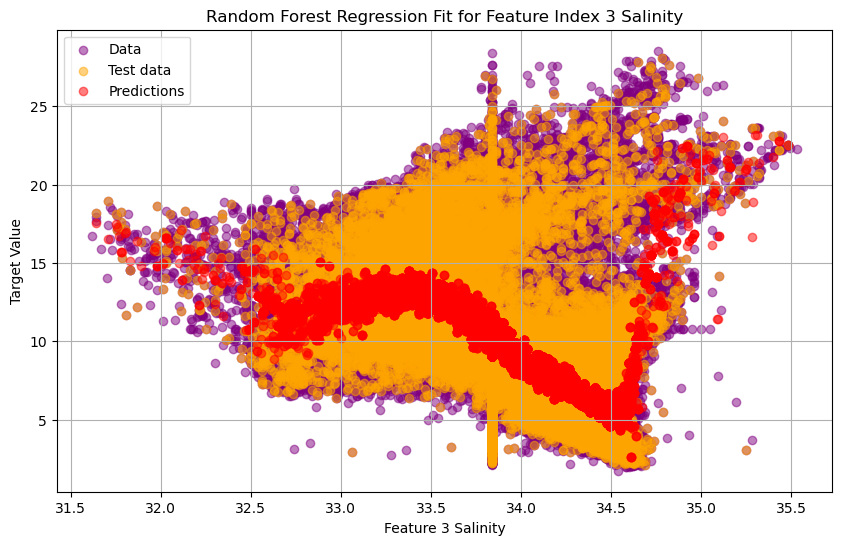

In [48]:
feature_index = 3
x_feature = X.iloc[:, feature_index].values.reshape(-1, 1)
X_train_feature, X_test_feature, y_train_feature, y_test_feature = train_test_split(x_feature, y, test_size=0.2, random_state=1)
rf_regfeature = RandomForestRegressor()
rf_regfeature.fit(X_train_feature, y_train_feature)
y_pred_feature = rf_regfeature.predict(X_test_feature)
plt.figure(figsize=(10, 6))
plt.scatter(x_feature, y, color='purple', label='Data', alpha=0.5)
plt.scatter(X_test_feature, y_test_feature, color='orange', label='Test data', alpha=0.5)
plt.scatter(X_test_feature, y_pred_feature, color='red', label='Predictions', alpha=0.5)
plt.title("Random Forest Regression Fit for Feature Index {} Salinity".format(feature_index))
plt.xlabel("Feature {}".format(feature_index)+' Salinity')
plt.ylabel("Target Value")
plt.legend()
plt.grid()
plt.show()

In [186]:
predictions=rf_reg.predict(X_test)
mse=mean_squared_error(y_test, predictions)
print(f'Mean Squared Error:{mse}')

Mean Squared Error:8.867044999996486e-07


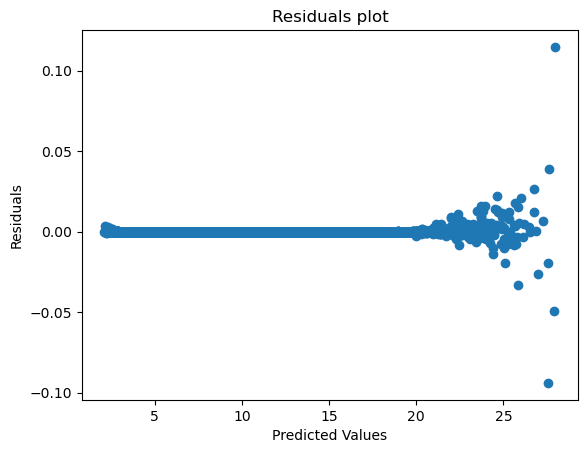

In [204]:
#Create a residuals plot
residuals=y_test-predictions
plt.scatter(predictions, residuals)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title('Residuals plot')
plt.show()

Optimization using Bayesian technique - Optuna

In [220]:
import optuna
def objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 100, 500)
    max_depth = trial.suggest_int('max_depth', 3, 10)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
    min_samples_leaf = trial.suggest_int('min_samples_leaf',1, 5)

    model = RandomForestRegressor(n_estimators=n_estimators,
                                   max_depth=max_depth,
                                   min_samples_split=min_samples_split,
                                   min_samples_leaf=min_samples_leaf,
                                   n_jobs=-1)
    model.fit(X_train, y_train)
    score = model.score(X_test, y_test)
    return -score
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=5)
best_params = study.best_params
best_model= RandomForestRegressor(**best_params, n_jobs=-1)
best_model.fit(X_train, y_train)
mse = mean_squared_error(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)
print("R-squared Score:", r2)

[I 2024-10-26 21:00:57,660] A new study created in memory with name: no-name-a25b7f32-dc63-4b45-ad7d-21017ba1031c
[I 2024-10-26 21:02:15,817] Trial 0 finished with value: -0.9984774496225334 and parameters: {'n_estimators': 366, 'max_depth': 5, 'min_samples_split': 5, 'min_samples_leaf': 2}. Best is trial 0 with value: -0.9984774496225334.
[I 2024-10-26 21:03:45,825] Trial 1 finished with value: -0.9996789553895529 and parameters: {'n_estimators': 357, 'max_depth': 6, 'min_samples_split': 3, 'min_samples_leaf': 3}. Best is trial 1 with value: -0.9996789553895529.
[I 2024-10-26 21:04:59,414] Trial 2 finished with value: -0.9984879946843153 and parameters: {'n_estimators': 351, 'max_depth': 5, 'min_samples_split': 4, 'min_samples_leaf': 1}. Best is trial 1 with value: -0.9996789553895529.
[I 2024-10-26 21:07:44,669] Trial 3 finished with value: -0.9999993677043227 and parameters: {'n_estimators': 338, 'max_depth': 9, 'min_samples_split': 10, 'min_samples_leaf': 2}. Best is trial 3 with v

Mean Squared Error: 8.867044999996486e-07
Mean Absolute Error: 3.352000001291854e-05
Root Mean Squared Error: 0.000941649881856122
R-squared Score: 0.9999999529887116


Optimization using RandomizedSearchCV, cross_val_score

In [241]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

best_score = -np.inf
best_params = {}

for _ in range(5):
    params = {k: v for k, v in zip(param_grid.keys(), [np.random.choice(v) for v in param_grid.values()])}
    model = RandomForestRegressor(**params, n_jobs=-1)
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
    mean_score = scores.mean()

    if mean_score > best_score:
        best_score = mean_score
        best_params = params

# Create the best model with the optimized hyperparameters
best_model = RandomForestRegressor(**best_params, n_jobs=-1)
best_model.fit(X_train, y_train)
mse = mean_squared_error(y_test, rf_predict)
mae = mean_absolute_error(y_test, rf_predict)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, rf_predict)
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)
print("R-squared Score:", r2)

Mean Squared Error: 1.082652749999592e-06
Mean Absolute Error: 3.552250001283044e-05
Root Mean Squared Error: 0.0010405060067100007
R-squared Score: 0.9999999425999296


Optimization using GridSearchCV, RandomizedSearchCV

In [245]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

# Define the parameter grid for Random Forest
param_grid = {
    'n_estimators': [25,50],
    'max_depth': [None, 10, ],
    'min_samples_split': [2],
    'min_samples_leaf': [1],
    'max_features': ['auto', 'sqrt']
}
rf_reg = RandomForestRegressor(random_state=42)
random_search = RandomizedSearchCV(estimator=rf_reg, param_distributions=param_grid, n_iter=5, cv=5, n_jobs=10, verbose=2, random_state=42)
random_search.fit(X_train, y_train)
best_params = random_search.best_params_
best_rf_reg = random_search.best_estimator_

print("Best Parameters:", best_params)
best_rf_reg.fit(X_train, y_train)
rf_predict = best_rf_reg.predict(X_test)
r_2_train = best_rf_reg.score(X_train, y_train)
r_2_test = best_rf_reg.score(X_test, y_test)
mse = mean_squared_error(y_test, rf_predict)
mae = mean_absolute_error(y_test, rf_predict)
rmse = np.sqrt(mse)

print("Root Mean Squared Error:", rmse)
print("R^2 train:", r_2_train)
print("R^2 test:", r_2_test)
print("MSE:", mse)
print("MAE:", mae)

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best Parameters: {'n_estimators': 25, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}
Root Mean Squared Error: 0.0784903868662914
R^2 train: 0.9999354839851449
R^2 test: 0.9996733699176171
MSE: 0.006160740830420089
MAE: 0.03296920449216197


Model Explainability Using PartialDependenceDisplay

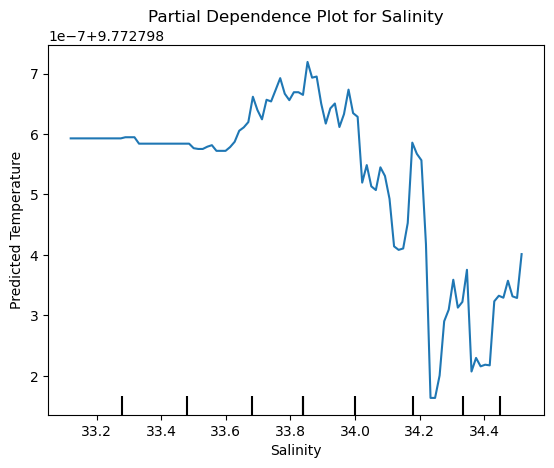

In [82]:
from sklearn.inspection import PartialDependenceDisplay
fig, ax = plt.subplots()
PartialDependenceDisplay.from_estimator(rf_reg, X_train, features=[3], ax=ax)
plt.title('Partial Dependence Plot for Salinity')
plt.xlabel('Salinity')
plt.ylabel('Predicted Temperature')
plt.show()

Model Explainability Using LIME

In [86]:
from lime.lime_tabular import LimeTabularExplainer
explainer = LimeTabularExplainer(X_train.values, feature_names=X_train.columns, mode='regression')
idx = 0  # For example, the first instance
exp = explainer.explain_instance(X_test.values[idx], rf_reg.predict, num_features=5)
exp.show_in_notebook(show_table=True)

/Users/steffidorothy/anaconda3/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


KNN Regressor

In [88]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
from sklearn.neighbors import KNeighborsRegressor
knnr = KNeighborsRegressor(n_neighbors=500)
knnr.fit(X_train,y_train)
y_pred_knnr = knnr.predict(X_test)

r_2_train[4] = knnr.score(X_train,y_train)
r_2_test[4] = knnr.score(X_test,y_test)
mse[4] = mean_squared_error(y_test, y_pred_knnr)
mae[4] = mean_absolute_error(y_test, y_pred_knnr)
rmse[4]=np.sqrt(mse[4])
print('\n RMSE', rmse[4])
print('\nR2 train score:', r_2_train[4])
print('\nR2 test score:', r_2_test[4])
print('\nMean Squared Error:', mse[4])
print('\nMean Absolute Error:', mae[4])


 RMSE 2.4877339843775728

R2 train score: 0.6679293654467373

R2 test score: 0.6647429521292905

Mean Squared Error: 6.188820377027114

Mean Absolute Error: 2.0258178788756087


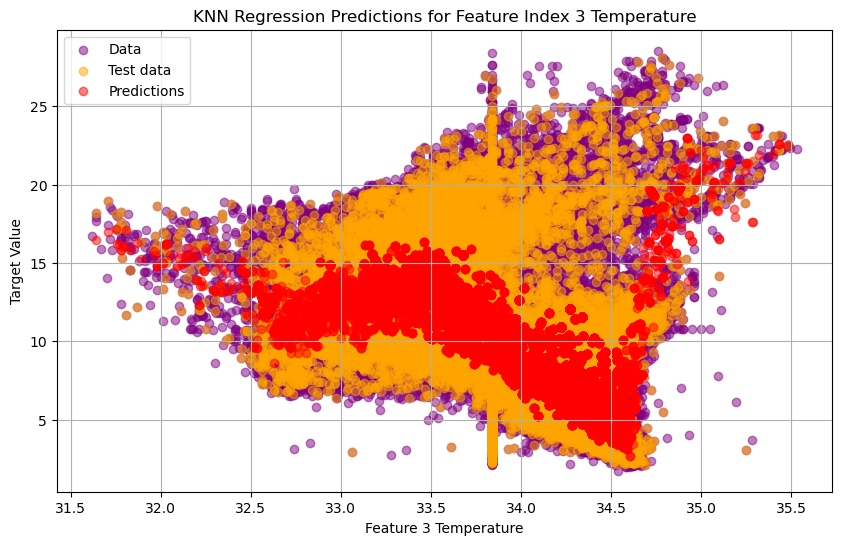

In [68]:
feature_index = 3
x_feature = X.iloc[:, feature_index].values.reshape(-1, 1)

X_train_feature, X_test_feature, y_train_feature, y_test_feature = train_test_split(x_feature, y, test_size=0.2, random_state=1)
knn_reg = KNeighborsRegressor(n_neighbors=5)
knn_reg.fit(X_train_feature, y_train_feature)

# Prediction on test set
y_pred_feature = knn_reg.predict(X_test_feature)
# Plotting (similar to Random Forest example)
plt.figure(figsize=(10, 6))
plt.scatter(x_feature, y, color='purple', label='Data', alpha=0.5)
plt.scatter(X_test_feature, y_test_feature, color='orange', label='Test data', alpha=0.5)
plt.scatter(X_test_feature, y_pred_feature, color='red', label='Predictions', alpha=0.5)
plt.title("KNN Regression Predictions for Feature Index {} Temperature".format(feature_index))
plt.xlabel("Feature {}".format(feature_index)+' Temperature')
plt.ylabel("Target Value")
plt.legend()
plt.grid()
plt.show()

Optimization with Bayesian Technique - Optuna

In [113]:
from optuna import create_study

def objective(trial):
    n_neighbors = trial.suggest_int("n_neighbors", 1, 60)
    weights = trial.suggest_categorical("weights", ["uniform", "distance"])

    # Create and train your KNN model with the suggested parameters
    knn_reg = KNeighborsRegressor(n_neighbors=n_neighbors, weights=weights)
    knn_reg.fit(X_train, y_train)  # Assuming X_train and y_train are defined
    
    # Calculate the evaluation metric (e.g., negative mean squared error)
    y_pred = knn_reg.predict(X_test) # Assuming X_test and y_test are defined
    metric_value = -mean_squared_error(y_test, y_pred)  # Negative MSE for minimization

    return metric_value

study = create_study(direction="minimize")
study.optimize(objective, n_trials=25)  # Adjust the number of trials as needed

best_params = study.best_trial.params
best_score = study.best_trial.value
print("Best Parameters:", best_params)
print("Best Objective Value (Neg. Mean Squared Error):", best_score)

[I 2024-10-27 05:08:59,952] A new study created in memory with name: no-name-7cce1497-305c-4d9f-b0c6-407637b71cfc
[I 2024-10-27 05:09:48,248] Trial 0 finished with value: -0.3538293831967951 and parameters: {'n_neighbors': 15, 'weights': 'distance'}. Best is trial 0 with value: -0.3538293831967951.
[I 2024-10-27 05:10:35,540] Trial 1 finished with value: -0.299618014366526 and parameters: {'n_neighbors': 4, 'weights': 'distance'}. Best is trial 0 with value: -0.3538293831967951.
[I 2024-10-27 05:11:23,990] Trial 2 finished with value: -0.3984604994127865 and parameters: {'n_neighbors': 22, 'weights': 'distance'}. Best is trial 2 with value: -0.3984604994127865.
[I 2024-10-27 05:11:59,657] Trial 3 finished with value: -0.8637718643555088 and parameters: {'n_neighbors': 47, 'weights': 'uniform'}. Best is trial 3 with value: -0.8637718643555088.
[I 2024-10-27 05:12:37,736] Trial 4 finished with value: -0.5420851829606133 and parameters: {'n_neighbors': 21, 'weights': 'uniform'}. Best is t

Best Parameters: {'n_neighbors': 60, 'weights': 'uniform'}
Best Objective Value (Neg. Mean Squared Error): -1.0405030605918173


Optimization using Grid search and Hyperparameter Tuning

In [119]:
param_grid = {
    'n_neighbors': [3, 5,7, 9, 11],
    'weights': ['uniform', 'distance']
}

grid_search = GridSearchCV(knnr, param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
best_score= grid_search.best_score_
print("Best Parameters:", best_params)
print("Best Cross-Validated Score:", best_score) 

Best Parameters: {'n_neighbors': 5, 'weights': 'distance'}
Best Cross-Validated Score: -0.33272922725737997


Optimization by generating polynomial features and cross validation

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
best_params = study.best_trial.params
# Generate polynomial features
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)
# Cross-validate the best model
best_knn = KNeighborsRegressor(**best_params)
cv_scores = cross_val_score(best_knn, X_train_poly, y_train, cv=5, scoring='neg_mean_squared_error')
print("Cross-validated MSE:", -cv_scores.mean())

Model Explainability

In [105]:
from lime.lime_tabular import LimeTabularExplainer
explainer = LimeTabularExplainer(X_train.values, feature_names=X_train.columns, mode='regression')
idx = 0  # For example, the first instance
exp = explainer.explain_instance(X_test.values[idx], knnr.predict, num_features=5)
exp.show_in_notebook(show_table=True)

/Users/steffidorothy/anaconda3/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(


In [ ]:
from sklearn.inspection import PartialDependenceDisplay

# Create the PDP plot
PartialDependenceDisplay.from_estimator(knnr, X_test, features=[3])
plt.show()

Evaluation

In [140]:
# Combine these lists into a 2D list
data = [rmse, r_2_train, r_2_test, mse, mae]
df = pd.DataFrame(data, columns=['Linear Regressor',  'Polynomial Regressor','Decision Tree Regressor', 'Random Forest Regressor', 'KNN Regressor'],
                  index=['RMSE','R^2 train', 'R^2 test', 'MSE', 'MAE'])
df = df.T

print(df)

                                 RMSE  R^2 train  R^2 test           MSE  \
Linear Regressor         2.953470e-15   1.000000  1.000000  8.722987e-30   
Polynomial Regressor     6.296674e-07   1.000000  1.000000  3.964810e-13   
Decision Tree Regressor  6.930352e-01   0.974097  0.974536  4.802978e-01   
Random Forest Regressor  1.040506e-03   1.000000  1.000000  1.082653e-06   
KNN Regressor            2.487734e+00   0.667929  0.664743  6.188820e+00   

                                  MAE  
Linear Regressor         2.256417e-15  
Polynomial Regressor     4.234374e-07  
Decision Tree Regressor  5.576632e-01  
Random Forest Regressor  3.552250e-05  
KNN Regressor            2.025818e+00  


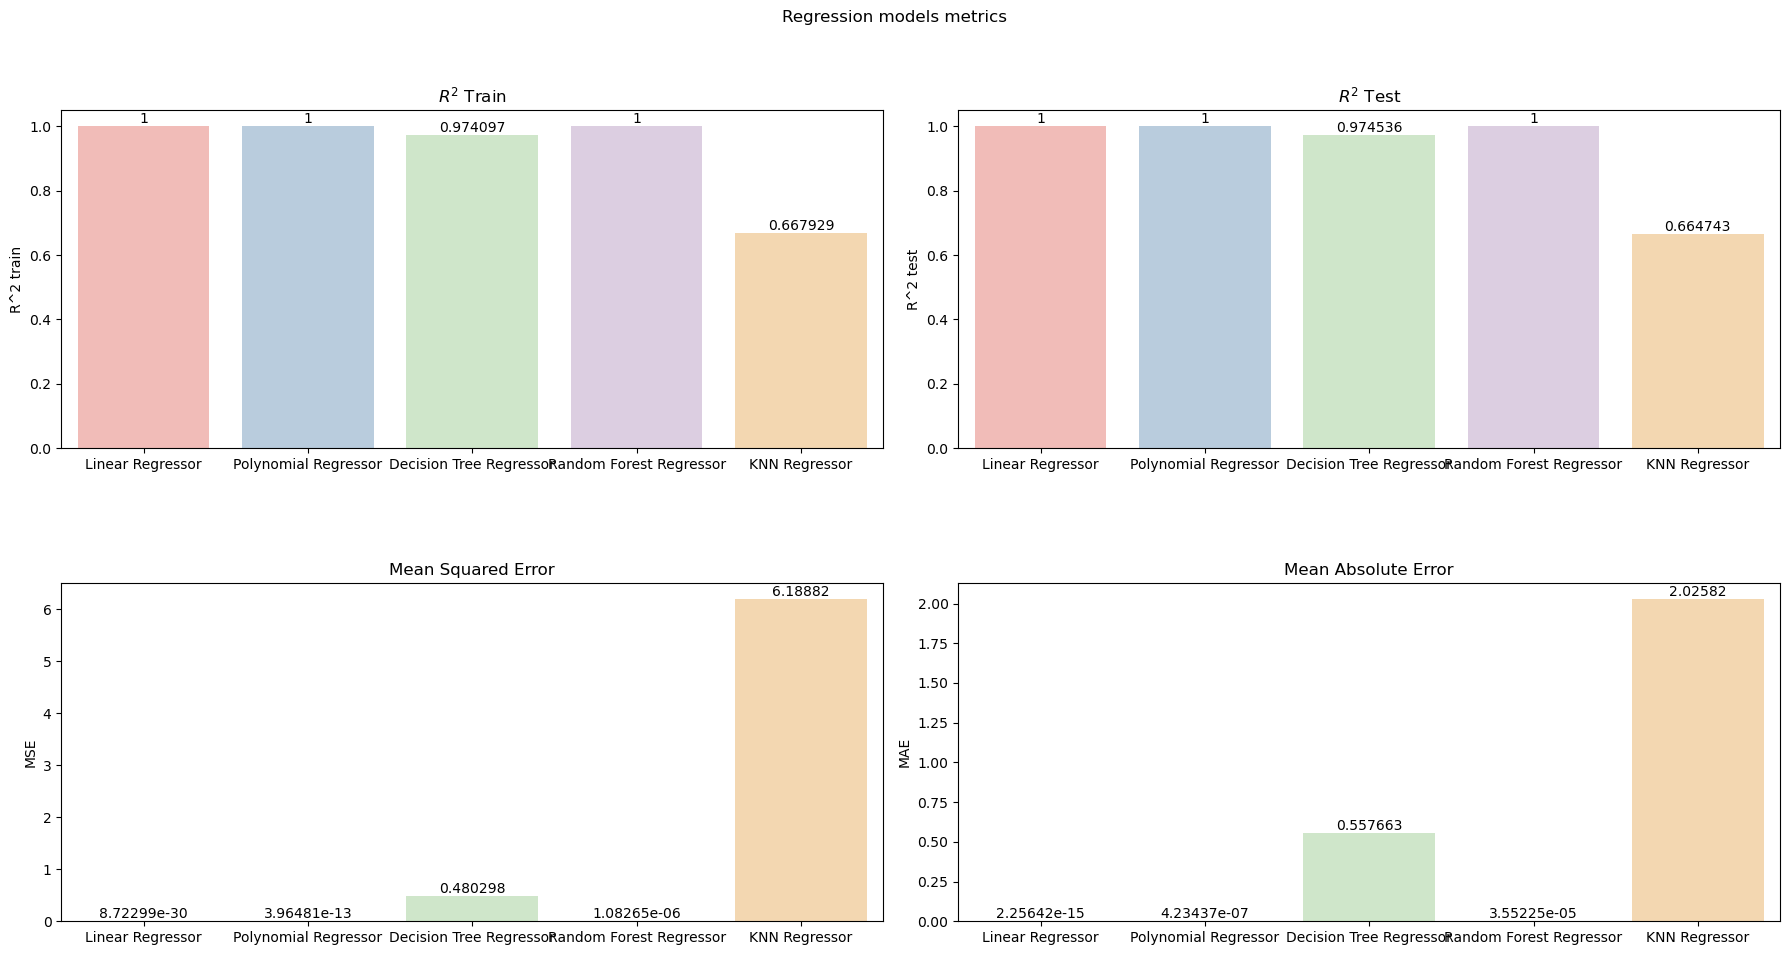

In [142]:
sns.color_palette("rocket")
fig, axs = plt.subplots(2, 2, figsize=(18,10))
fig.suptitle('Regression models metrics')
ax1=sns.barplot(ax=axs[0, 0],data=df, x=df.index.values, y='R^2 train',palette='Pastel1')
ax1.bar_label(ax1.containers[0])
axs[0,0].set_title('$R^2$ Train')
ax2=sns.barplot(ax=axs[0, 1],data=df, x=df.index.values, y='R^2 test', palette='Pastel1')
ax2.bar_label(ax2.containers[0])
axs[0,1].set_title('$R^2$ Test')
ax3=sns.barplot(ax=axs[1, 0],data=df, x=df.index.values, y='MSE',palette='Pastel1')
ax3.bar_label(ax3.containers[0])
axs[1,0].set_title('Mean Squared Error')
ax4=sns.barplot(ax=axs[1, 1],data=df, x=df.index.values, y='MAE',palette='Pastel1')
ax4.bar_label(ax4.containers[0])
axs[1,1].set_title('Mean Absolute Error')
# Adjust layout to prevent overlap
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.subplots_adjust(hspace=0.4)
plt.show()

In [144]:
import keras as keras
from keras import layers
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
from keras import metrics

2024-10-26 23:56:17.432169: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [146]:
# Creating train and test dataset
msk = np.random.rand(len(bottle)) < 0.8
train_raw = bottle[msk]
test_raw = bottle[~msk]

In [148]:
# Fixing missing values issue and imputing
imputer = SimpleImputer()
train = pd.DataFrame(imputer.fit_transform(train_raw))
train.columns = bottle.columns
train.rename(columns={'T_degC': 'TEMP', 'Salnty': 'SALINITY', 'Depthm': 'DEPTH'}, inplace=True)
train = train.reindex(columns={'SALINITY', 'DEPTH', 'TEMP'})
print(train.head())

    TEMP  DEPTH  SALINITY
0  10.46    8.0    33.440
1  10.46   10.0    33.437
2  10.45   19.0    33.420
3  10.45   20.0    33.421
4  10.45   30.0    33.431


In [150]:
train_x = train[['SALINITY', 'DEPTH']]
train_y = train[['TEMP']]

In [152]:
# Splitting into train and test dataset
X_train_full, X_test, y_train_full, y_test = train_test_split(train_x, train_y, random_state=0)
X_train, X_valid, y_train, y_valid = train_test_split(X_train_full, y_train_full, random_state=1)

In [154]:
# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)
X_test = scaler.transform(X_test)

In [156]:
input_ = layers.Input(shape=X_train.shape[1:])
hidden1 = layers.Dense(16, activation="relu")(input_)
hidden2 = layers.Dense(8, activation="relu")(hidden1)
concat = layers.Concatenate()([input_, hidden2])
output = layers.Dense(1)(concat)
model = keras.Model(inputs=[input_], outputs=[output])
model.compile(loss="mean_squared_error", optimizer="sgd", metrics = [metrics.mean_absolute_percentage_error, 'mae'])

In [158]:
# Fitting
history = model.fit(X_train, y_train, epochs=10, validation_data=(X_valid, y_valid))

Epoch 1/10


/Users/steffidorothy/anaconda3/lib/python3.11/site-packages/keras/src/models/functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['keras_tensor']. Received: the structure of inputs=*
  warnings.warn(


2802/2809 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5.2883 - mae: 1.4666 - mean_absolute_percentage_error: 13.9503

/Users/steffidorothy/anaconda3/lib/python3.11/site-packages/keras/src/models/functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['keras_tensor']. Received: the structure of inputs=*
  warnings.warn(


2809/2809 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - loss: 5.2837 - mae: 1.4660 - mean_absolute_percentage_error: 13.9454 - val_loss: 4.2666 - val_mae: 1.3220 - val_mean_absolute_percentage_error: 11.2256
Epoch 2/10
2809/2809 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - loss: 3.1966 - mae: 1.2018 - mean_absolute_percentage_error: 11.2757 - val_loss: 3.0808 - val_mae: 1.1630 - val_mean_absolute_percentage_error: 10.8878
Epoch 3/10
2809/2809 ━━━━━━━━━━━━━━━━━━━━ 17s 6ms/step - loss: 3.1827 - mae: 1.1955 - mean_absolute_percentage_error: 11.1653 - val_loss: 3.6157 - val_mae: 1.3203 - val_mean_absolute_percentage_error: 12.8121
Epoch 4/10
2809/2809 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - loss: 3.1156 - mae: 1.1796 - mean_absolute_percentage_error: 11.0144 - val_loss: 5.7195 - val_mae: 1.5610 - val_mean_absolute_percentage_error: 13.4746
Epoch 5/10
2809/2809 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - loss: 3.1169 - mae: 1.1804 - mean_absolute_percentage_error: 11.0106 - val_loss: 3.0691 - val_mae: 1.1809 - val_mean_a

In [160]:
loss = model.evaluate(X_test, y_test)

1249/1249 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 3.1006 - mae: 1.1556 - mean_absolute_percentage_error: 10.3681


In [162]:
acc = model.evaluate(X_test, y_test)

1249/1249 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 3.1000 - mae: 1.1555 - mean_absolute_percentage_error: 10.3673


In [164]:
history = model.fit(X_train, y_train, epochs=20, validation_data=(X_valid, y_valid))

Epoch 1/20
2809/2809 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - loss: 3.0757 - mae: 1.1685 - mean_absolute_percentage_error: 10.8536 - val_loss: 3.0435 - val_mae: 1.1535 - val_mean_absolute_percentage_error: 10.5376
Epoch 2/20
2809/2809 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - loss: 3.0761 - mae: 1.1710 - mean_absolute_percentage_error: 10.8808 - val_loss: 3.0261 - val_mae: 1.1537 - val_mean_absolute_percentage_error: 10.7587
Epoch 3/20
2809/2809 ━━━━━━━━━━━━━━━━━━━━ 25s 7ms/step - loss: 3.0873 - mae: 1.1735 - mean_absolute_percentage_error: 10.9238 - val_loss: 3.1014 - val_mae: 1.1743 - val_mean_absolute_percentage_error: 11.1398
Epoch 4/20
2809/2809 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 3.0863 - mae: 1.1752 - mean_absolute_percentage_error: 10.9397 - val_loss: 2.9974 - val_mae: 1.1492 - val_mean_absolute_percentage_error: 10.7697
Epoch 5/20
2809/2809 ━━━━━━━━━━━━━━━━━━━━ 17s 6ms/step - loss: 3.0713 - mae: 1.1700 - mean_absolute_percentage_error: 10.8736 - val_loss: 3.0089 - val_mae: 1.1695 -

In [166]:
loss = model.evaluate(X_test, y_test)

1249/1249 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 3.4333 - mae: 1.2695 - mean_absolute_percentage_error: 12.0143


In [168]:
acc = model.evaluate(X_test, y_test)

1249/1249 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 3.4343 - mae: 1.2697 - mean_absolute_percentage_error: 12.0154


In [170]:
# Predicting
pred = model.predict(X_test)
# Accuracy measures
print("Mean absolute error: %.2f" % np.mean(np.absolute(pred - np.asanyarray(y_test))))
print("Residual sum of squares (MSE): %.2f" % np.mean((pred - np.asanyarray(y_test)) ** 2))
print("R2-score: %.2f" % r2_score(pred, np.asanyarray(y_test)))

  32/1249 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step  

/Users/steffidorothy/anaconda3/lib/python3.11/site-packages/keras/src/models/functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['keras_tensor']. Received: the structure of inputs=*
  warnings.warn(


1249/1249 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
Mean absolute error: 1.26
Residual sum of squares (MSE): 3.40
R2-score: 0.76


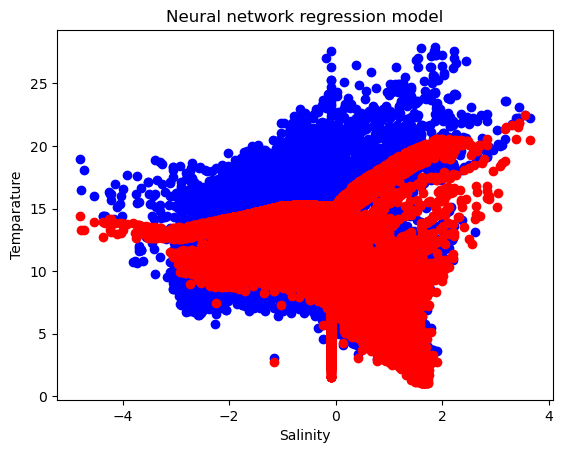

In [172]:
# Plotting
plt.scatter(pd.DataFrame(X_test[:,0]), y_test, color='blue')
plt.scatter(pd.DataFrame(X_test[:,0]), pred, color='red')
plt.title('Neural network regression model')
plt.xlabel("Salinity")
plt.ylabel("Temparature")
plt.show()